# Sydney Housing Price Prediction
## SIT307 8.1D - Machine Learning Mini Project
**Manmeet Kaur**

In this project, I used data from 105 sold properties in Mosman, Parramatta and Campbelltown. I wanted to compare three regression models and see how well they could estimate sale prices from basic property details.

I started by checking the data, then explored the price patterns, compared the models and looked closely at the five largest prediction errors. I also used the selected model in a Streamlit app for single-property and CSV predictions. Ridge regression gave the lowest average error in this comparison, although the errors were still large for some expensive Mosman properties.

**To run the notebook:** choose **Restart Kernel and Run All Cells** in Jupyter. The cleaned CSV can stay in the same folder as this notebook. An identical copy is also included inside the notebook as a fallback. The results and app files are saved in `SIT307_8_1D_outputs`.


## 0. Setting up the notebook

I used the same random seed, 42, throughout the analysis so the data splits could be reproduced. The setup cells below import the packages, record their versions and create the output folders.

The first cell installs a package only if it is missing from the current Jupyter environment. If a package is updated manually, the kernel needs to be restarted before running all the cells again. The code requires scikit-learn 1.5 or later.


In [1]:
import importlib.util
import subprocess
import sys

AUTO_INSTALL_MISSING = True
required_packages = {
    "numpy": "numpy>=1.26,<3", "pandas": "pandas>=2.2,<3",
    "matplotlib": "matplotlib>=3.8,<4", "sklearn": "scikit-learn>=1.5,<2",
    "joblib": "joblib>=1.3,<2",
}
missing_packages = [spec for name, spec in required_packages.items()
                    if importlib.util.find_spec(name) is None]
if missing_packages:
    if not AUTO_INSTALL_MISSING:
        raise ImportError("Install in this kernel with %pip install " + " ".join(missing_packages))
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_packages])
print("Core packages are available in the active Jupyter kernel.")

Core packages are available in the active Jupyter kernel.


In [2]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import shutil
import zipfile
import platform
import time
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")  # Static figures work in both Jupyter and headless execution.
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
import sklearn
import joblib
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from IPython.display import display, Markdown, FileLink, Image

if tuple(int(v) for v in sklearn.__version__.split(".")[:2]) < (1, 5):
    raise RuntimeError("Upgrade scikit-learn with %pip install -U scikit-learn, restart the kernel, and rerun.")
SEED = 42
OUTER_FOLDS = 5
INNER_FOLDS = 3
CV_JOBS = 1  # Small dataset; safe default for a laptop.
np.random.seed(SEED)
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 180, "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.max_columns", 20)
pd.set_option("display.max_colwidth", 90)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

WORK_DIR = Path.cwd() / "SIT307_8_1D_outputs"
FIG_DIR = WORK_DIR / "figures"
TABLE_DIR = WORK_DIR / "tables"
APP_DIR = WORK_DIR / "app"
for directory in [WORK_DIR, FIG_DIR, TABLE_DIR, APP_DIR, WORK_DIR / "data"]:
    directory.mkdir(parents=True, exist_ok=True)
versions = {"python": platform.python_version(), "numpy": np.__version__,
            "pandas": pd.__version__, "scikit-learn": sklearn.__version__,
            "matplotlib": plt.matplotlib.__version__, "joblib": joblib.__version__}
print("Versions:", versions)
print("Results will be saved in:", WORK_DIR)

def show_and_save(fig, name):
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"{name}.png", bbox_inches="tight")
    display(Image(filename=str(FIG_DIR / f"{name}.png")))
    plt.close(fig)

def score_predictions(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    if not np.isfinite(predicted).all():
        raise ValueError("Non-finite predictions were produced.")
    return {"MAE_AUD": mean_absolute_error(actual, predicted),
            "RMSE_AUD": np.sqrt(mean_squared_error(actual, predicted)),
            "R2": r2_score(actual, predicted)}

Versions: {'python': '3.12.14', 'numpy': '2.3.5', 'pandas': '2.2.3', 'scikit-learn': '1.8.0', 'matplotlib': '3.10.8', 'joblib': '1.5.3'}
Results will be saved in: /workspace/scratch/b108e072d98e/output/code/SIT307_8_1D_Project/SIT307_8_1D_outputs


### Loading the CSV

I left `DATA_PATH = None` so the notebook can find `sydney_housing_final_105_CLEANED.csv` in the same folder. If the file is not there, it uses the copy included below.

To use a different location, I can replace `None` with the actual path, for example `Path.home() / "Downloads" / "sydney_housing_final_105_CLEANED.csv"`. For Colab, Google Drive needs to be mounted first. If I enter a path that does not exist, the code stops instead of quietly using another file.


In [3]:
DATA_PATH = None  # Example: Path.home() / "Downloads" / "sydney_housing_final_105_CLEANED.csv"
DATA_FILENAME = 'sydney_housing_final_105_CLEANED.csv'
EMBEDDED_CSV = 'property_id,suburb,postcode,address,sale_date,sale_price,bedrooms,bathrooms,parking,land_size_m2,reported_land_size_m2,property_type,source_page,verification_url,verification_status,land_size_quality,needs_land_imputation,land_size_note\n1,Mosman,2088,"177A Spit Road, Mosman NSW 2088",2026-09-16,3200000,3,2,2,245,245,House,"https://www.realestate.com.au/sold/property-house-in-mosman,+nsw+2088/list-1",https://www.realestate.com.au/property/177a-spit-rd-mosman-nsw-2088/,individual_property_page_checked,recovered,no,Missing land size recovered from the individual Realestate.com.au property page.\n2,Mosman,2088,"5 Botanic Road, Mosman NSW 2088",2026-07-22,8700000,4,3,2,437,437,House,"https://www.realestate.com.au/sold/property-house-in-mosman,+nsw+2088/list-1",https://www.realestate.com.au/property/5-botanic-rd-mosman-nsw-2088/,individual_property_page_checked,recovered,no,Missing land size recovered from the individual Realestate.com.au property page.\n3,Mosman,2088,"105 Holt Avenue, Mosman NSW 2088",2026-06-05,3550000,4,3,0,,,House,"https://www.realestate.com.au/sold/property-house-in-mosman,+nsw+2088/list-1",https://www.realestate.com.au/property/105-holt-ave-mosman-nsw-2088/,individual_property_page_checked,unavailable,yes,Land size unavailable; impute within each training fold only.\n4,Mosman,2088,"96 Glover Street, Mosman NSW 2088",2026-06-02,3390000,4,3,2,379.0,379.0,House,"https://www.realestate.com.au/sold/property-house-in-mosman,+nsw+2088/list-1",,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n5,Mosman,2088,"14 Erith Street, Mosman NSW 2088",2026-04-11,5300000,4,3,1,613.0,613.0,House,"https://www.realestate.com.au/sold/property-house-in-mosman,+nsw+2088/list-1",,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n6,Mosman,2088,"130 Cowles Road, Mosman NSW 2088",2026-04-11,4200000,5,2,1,412,412,House,"https://www.realestate.com.au/sold/property-house-in-mosman,+nsw+2088/list-1",https://www.realestate.com.au/property/130-cowles-rd-mosman-nsw-2088/,individual_property_page_checked,recovered,no,Missing land size recovered from the individual Realestate.com.au property page.\n7,Mosman,2088,"17 Morella Road, Mosman NSW 2088",2026-03-31,23000000,4,3,2,961.1,961.1,House,"https://www.realestate.com.au/sold/property-house-in-mosman,+nsw+2088/list-1",,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n8,Mosman,2088,"34 Rickard Avenue, Mosman NSW 2088",2026-03-27,9000000,7,3,2,721,721,House,"https://www.realestate.com.au/sold/property-house-in-mosman,+nsw+2088/list-1",https://www.realestate.com.au/property/34-rickard-ave-mosman-nsw-2088/,individual_property_page_checked,recovered,no,Missing land size recovered from the individual Realestate.com.au property page.\n9,Mosman,2088,"10 Cyprian Street, Mosman NSW 2088",2026-03-27,8500000,4,3,2,556.4,556.4,House,"https://www.realestate.com.au/sold/property-house-in-mosman,+nsw+2088/list-1",,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n10,Mosman,2088,"29 Pearl Bay Avenue, Mosman NSW 2088",2026-03-20,7198000,4,3,3,658,658,House,"https://www.realestate.com.au/sold/property-house-in-mosman,+nsw+2088/list-1",https://www.realestate.com.au/property/29-pearl-bay-ave-mosman-nsw-2088/,individual_property_page_checked,recovered,no,Missing land size recovered from the individual Realestate.com.au property page.\n11,Mosman,2088,"31 Ryrie Street, Mosman NSW 2088",2026-03-07,3900000,5,3,2,624.0,624.0,House,"https://www.realestate.com.au/sold/property-house-in-mosman,+nsw+2088/list-1",,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n12,Mosman,2088,"53 Clanalpine Street, Mosman NSW 2088",2026-03-06,7700000,5,5,4,511.0,511.0,House,"https://www.realestate.com.au/sold/property-house-in-mosman,+nsw+2088/list-1",,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n13,Mosman,2088,"33 Spofforth Street, Mosman NSW 2088",2026-03-02,5075000,4,3,3,462,462,House,"https://www.realestate.com.au/sold/property-house-in-mosman,+nsw+2088/list-1",https://www.realestate.com.au/property/33-spofforth-st-mosman-nsw-2088/,individual_property_page_checked,recovered,no,Missing land size recovered from the individual Realestate.com.au property page.\n14,Mosman,2088,"1 Bray Street, Mosman NSW 2088",2026-02-27,3750000,3,2,1,296.0,296.0,House,"https://www.realestate.com.au/sold/property-house-in-mosman,+nsw+2088/list-1",,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n15,Mosman,2088,"46 Spencer Road, Mosman NSW 2088",2026-02-16,3990000,4,2,0,233.0,233.0,House,"https://www.realestate.com.au/sold/property-house-in-mosman,+nsw+2088/list-1",https://www.realestate.com.au/property/46-spencer-rd-mosman-nsw-2088/,individual_property_page_checked,available,no,Land size retained from the sold-search dataset.\n16,Mosman,2088,"6 Lavoni Street, Mosman NSW 2088",2025-12-05,11550000,7,4,3,715.0,715.0,House,"https://www.realestate.com.au/sold/property-house-in-mosman,+nsw+2088/list-1",,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n17,Mosman,2088,"22B Inkerman Street, Mosman NSW 2088",2025-12-05,6900000,4,3,2,404,404,House,"https://www.realestate.com.au/sold/property-house-in-mosman,+nsw+2088/list-1",https://www.realestate.com.au/property/22b-inkerman-st-mosman-nsw-2088/,individual_property_page_checked,recovered,no,Missing land size recovered from the individual Realestate.com.au property page.\n18,Mosman,2088,"26 Vista Street, Mosman NSW 2088",2025-12-05,4320000,4,2,1,321.0,321.0,House,"https://www.realestate.com.au/sold/property-house-in-mosman,+nsw+2088/list-1",,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n19,Mosman,2088,"56 Spencer Road, Mosman NSW 2088",2025-11-22,3850000,4,3,0,226,226,House,"https://www.realestate.com.au/sold/property-house-in-mosman,+nsw+2088/list-1",https://www.realestate.com.au/property/56-spencer-rd-mosman-nsw-2088/,individual_property_page_checked,recovered,no,Missing land size recovered from the individual Realestate.com.au property page.\n20,Mosman,2088,"15 Balmoral Avenue, Mosman NSW 2088",2025-11-19,15880000,5,4,2,788.0,788.0,House,"https://www.realestate.com.au/sold/property-house-in-mosman,+nsw+2088/list-1",,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n21,Mosman,2088,"30 Beauty Point Road, Mosman NSW 2088",2025-11-17,11000000,5,5,3,879.0,879.0,House,"https://www.realestate.com.au/sold/property-house-in-mosman,+nsw+2088/list-1",,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n22,Mosman,2088,"94A Raglan Street, Mosman NSW 2088",2025-11-15,3700000,3,2,1,224,224,House,"https://www.realestate.com.au/sold/property-house-in-mosman,+nsw+2088/list-1",https://www.realestate.com.au/property/94a-raglan-st-mosman-nsw-2088/,individual_property_page_checked,recovered,no,Missing land size recovered from the individual Realestate.com.au property page.\n23,Mosman,2088,"7 Cross Street, Mosman NSW 2088",2025-11-14,10100000,6,3,2,695.6,695.6,House,"https://www.realestate.com.au/sold/property-house-in-mosman,+nsw+2088/list-1",,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n24,Mosman,2088,"110 Awaba Street, Mosman NSW 2088",2025-10-30,5230000,5,4,1,479.1,479.1,House,"https://www.realestate.com.au/sold/property-house-in-mosman,+nsw+2088/list-1",,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n25,Mosman,2088,"40 Stanley Avenue, Mosman NSW 2088",2025-10-09,20000000,5,5,2,920.0,920.0,House,"https://www.realestate.com.au/sold/property-house-in-mosman,+nsw+2088/list-2",,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n26,Mosman,2088,"35 Lang Street, Mosman NSW 2088",2025-09-27,5250000,5,3,1,468.0,468.0,House,"https://www.realestate.com.au/sold/property-house-in-mosman,+nsw+2088/list-2",,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n27,Mosman,2088,"16 Bay Street, Mosman NSW 2088",2025-09-20,7350000,5,4,3,806.0,806.0,House,"https://www.realestate.com.au/sold/property-house-in-mosman,+nsw+2088/list-2",,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n28,Mosman,2088,"34 Harbour Street, Mosman NSW 2088",2025-09-20,3400000,4,1,1,261,261,House,"https://www.realestate.com.au/sold/property-house-in-mosman,+nsw+2088/list-2",https://www.realestate.com.au/property/34-harbour-st-mosman-nsw-2088/,individual_property_page_checked,recovered,no,Missing land size recovered from the individual Realestate.com.au property page.\n29,Mosman,2088,"27 Prince Street, Mosman NSW 2088",2025-08-30,3600000,3,1,1,300.0,300.0,House,"https://www.realestate.com.au/sold/property-house-in-mosman,+nsw+2088/list-2",,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n30,Mosman,2088,"3 Want Street, Mosman NSW 2088",2025-08-23,3325000,4,1,0,246,246,House,"https://www.realestate.com.au/sold/property-house-in-mosman,+nsw+2088/list-2",https://www.realestate.com.au/property/3-want-st-mosman-nsw-2088/,individual_property_page_checked,recovered,no,Missing land size recovered from the individual Realestate.com.au property page.\n31,Mosman,2088,"5 The Grove, Mosman NSW 2088",2025-08-16,11360000,4,3,4,660.0,660.0,House,"https://www.realestate.com.au/sold/property-house-in-mosman,+nsw+2088/list-2",,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n32,Mosman,2088,"46 Royalist Road, Mosman NSW 2088",2025-08-09,5700000,5,3,2,468.0,468.0,House,"https://www.realestate.com.au/sold/property-house-in-mosman,+nsw+2088/list-2",,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n33,Mosman,2088,"16 Upper Spit Road, Mosman NSW 2088",2025-08-02,6050000,5,5,2,712,712,House,"https://www.realestate.com.au/sold/property-house-in-mosman,+nsw+2088/list-2",https://www.realestate.com.au/property/16-upper-spit-rd-mosman-nsw-2088/,individual_property_page_checked,recovered,no,Missing land size recovered from the individual Realestate.com.au property page.\n34,Mosman,2088,"37 Carrington Avenue, Mosman NSW 2088",2025-06-12,21500000,5,4,2,751,751,House,"https://www.realestate.com.au/sold/property-house-in-mosman,+nsw+2088/list-2",https://www.realestate.com.au/property/37-carrington-ave-mosman-nsw-2088/,individual_property_page_checked,recovered,no,Missing land size recovered from the individual Realestate.com.au property page.\n35,Mosman,2088,"67 Raglan Street, Mosman NSW 2088",2025-06-06,9650000,5,3,2,904.0,904.0,House,"https://www.realestate.com.au/sold/property-house-in-mosman,+nsw+2088/list-2",,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n36,Parramatta,2150,"124 Thomas Street, Parramatta NSW 2150",2026-06-27,2300000,3,1,1,739.0,739.0,House,https://www.realestate.com.au/sold/property-house-in-parramatta/list-1,,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n37,Parramatta,2150,"11 Pemberton Street, Parramatta NSW 2150",2026-05-27,1610000,3,1,1,461.6,461.6,House,https://www.realestate.com.au/sold/property-house-in-parramatta/list-1,,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n38,Parramatta,2150,"51 Gore Street, Parramatta NSW 2150",2026-05-16,1480000,3,1,1,461.6,461.6,House,https://www.realestate.com.au/sold/property-house-in-parramatta/list-1,,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n39,Parramatta,2150,"28 Marsden Street, Parramatta NSW 2150",2026-05-02,1555000,3,1,1,505.9,505.9,House,https://www.realestate.com.au/sold/property-house-in-parramatta/list-1,,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n40,Parramatta,2150,"13 Morton Street, Parramatta NSW 2150",2026-04-20,1800000,4,3,2,461.6,461.6,House,https://www.realestate.com.au/sold/property-house-in-parramatta/list-1,,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n41,Parramatta,2150,"58 Crimea Street, Parramatta NSW 2150",2026-02-09,1620000,3,2,2,613.4,613.4,House,https://www.realestate.com.au/sold/property-house-in-parramatta/list-1,,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n42,Parramatta,2150,"114 Thomas Street, Parramatta NSW 2150",2025-12-13,1360000,3,2,1,381.0,381.0,House,https://www.realestate.com.au/sold/property-house-in-parramatta/list-1,,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n43,Parramatta,2150,"7 Trott Street, Parramatta NSW 2150",2025-12-06,1150000,2,1,2,289,289,House,https://www.realestate.com.au/sold/property-house-in-parramatta/list-1,https://www.realestate.com.au/property/7-trott-st-parramatta-nsw-2150/,individual_property_page_checked,recovered,no,Missing land size recovered from the individual Realestate.com.au property page.\n44,Parramatta,2150,"38 Inkerman Street, Parramatta NSW 2150",2025-11-15,2010500,3,2,4,698.6,698.6,House,https://www.realestate.com.au/sold/property-house-in-parramatta/list-1,,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n45,Parramatta,2150,"71 Pitt Street, Parramatta NSW 2150",2025-09-27,1771000,6,2,5,455.3,455.3,House,https://www.realestate.com.au/sold/property-house-in-parramatta/list-1,,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n46,Parramatta,2150,"9 Carrington Street, Parramatta NSW 2150",2025-09-20,1785000,5,3,2,455.0,455.0,House,https://www.realestate.com.au/sold/property-house-in-parramatta/list-1,,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n47,Parramatta,2150,"76 O\'Connell Street, Parramatta NSW 2150",2025-07-05,1150000,3,1,1,253.0,253.0,House,https://www.realestate.com.au/sold/property-house-in-parramatta/list-1,,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n48,Parramatta,2150,"41 Gore Street, Parramatta NSW 2150",2025-06-16,1660000,3,2,1,449.0,449.0,House,https://www.realestate.com.au/sold/property-house-in-parramatta/list-1,,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n49,Parramatta,2150,"4 Alma Street, Parramatta NSW 2150",2025-06-14,1430000,3,1,2,582.0,582.0,House,https://www.realestate.com.au/sold/property-house-in-parramatta/list-1,,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n50,Parramatta,2150,"8 Gould Place, Parramatta NSW 2150",2025-06-06,1950000,3,3,2,467.9,467.9,House,https://www.realestate.com.au/sold/property-house-in-parramatta/list-1,,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n51,Parramatta,2150,"158 Railway Street, Parramatta NSW 2150",2025-05-24,1472000,3,1,2,455.3,455.3,House,https://www.realestate.com.au/sold/property-house-in-parramatta/list-1,,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n52,Parramatta,2150,"113 Railway Street, Parramatta NSW 2150",2025-05-21,830000,2,1,0,240,240,House,https://www.realestate.com.au/sold/property-house-in-parramatta/list-1,https://www.realestate.com.au/property/113-railway-st-parramatta-nsw-2150/,individual_property_page_checked,recovered,no,Missing land size recovered from the individual Realestate.com.au property page.\n53,Parramatta,2150,"33 Morton Street, Parramatta NSW 2150",2025-05-10,1672000,4,2,2,455.3,455.3,House,https://www.realestate.com.au/sold/property-house-in-parramatta/list-1,,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n54,Parramatta,2150,"22 Young Street, Parramatta NSW 2150",2025-05-10,1230000,3,1,2,325,325,House,https://www.realestate.com.au/sold/property-house-in-parramatta/list-1,https://www.realestate.com.au/property/22-young-st-parramatta-nsw-2150/,individual_property_page_checked,recovered,no,Missing land size recovered from the individual Realestate.com.au property page.\n55,Parramatta,2150,"12 Noller Parade, Parramatta NSW 2150",2025-05-09,2360000,6,3,2,560.0,560.0,House,https://www.realestate.com.au/sold/property-house-in-parramatta/list-1,,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n56,Parramatta,2150,"30 Wandsworth Street, Parramatta NSW 2150",2025-05-03,1540000,2,1,2,332.0,332.0,House,https://www.realestate.com.au/sold/property-house-in-parramatta/list-1,,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n57,Parramatta,2150,"6 Carrington Street, Parramatta NSW 2150",2025-04-29,1700000,3,2,3,670.0,670.0,House,https://www.realestate.com.au/sold/property-house-in-parramatta/list-1,,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n58,Parramatta,2150,"6 Wandsworth Street, Parramatta NSW 2150",2025-04-12,1800000,4,1,2,543.7,543.7,House,https://www.realestate.com.au/sold/property-house-in-parramatta/list-1,,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n59,Parramatta,2150,"109 Victoria Road, Parramatta NSW 2150",2025-03-20,1248000,5,2,0,396.0,396.0,House,https://www.realestate.com.au/sold/property-house-in-parramatta/list-2,https://www.realestate.com.au/sold/property-house-nsw-parramatta-146028960,individual_property_page_checked,available,no,Land size retained from the sold-search dataset.\n60,Parramatta,2150,"84 Crimea Street, Parramatta NSW 2150",2025-02-28,2170000,5,3,2,303.0,303.0,House,https://www.realestate.com.au/sold/property-house-in-parramatta/list-2,,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n61,Parramatta,2150,"100 Crimea Street, Parramatta NSW 2150",2025-02-22,1200000,3,2,1,303.5,303.5,House,https://www.realestate.com.au/sold/property-house-in-parramatta/list-2,,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n62,Parramatta,2150,"18 Glebe Street, Parramatta NSW 2150",2025-01-10,1850000,3,1,1,423.7,423.7,House,https://www.realestate.com.au/sold/property-house-in-parramatta/list-2,,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n63,Parramatta,2150,"10 Fennell Street, Parramatta NSW 2150",2024-12-20,1800000,3,1,1,685,685,House,https://www.realestate.com.au/sold/property-house-in-parramatta/list-2,https://www.realestate.com.au/property/10-fennell-st-parramatta-nsw-2150/,individual_property_page_checked,recovered,no,Missing land size recovered from the individual Realestate.com.au property page.\n64,Parramatta,2150,"5 Gould Place, Parramatta NSW 2150",2024-12-07,2002000,3,1,2,358,358,House,https://www.realestate.com.au/sold/property-house-in-parramatta/list-2,https://www.realestate.com.au/property/5-gould-pl-parramatta-nsw-2150/,individual_property_page_checked,recovered,no,Missing land size recovered from the individual Realestate.com.au property page.\n65,Parramatta,2150,"13 Gore Street, Parramatta NSW 2150",2024-11-23,1560000,3,2,2,463,463,House,https://www.realestate.com.au/sold/property-house-in-parramatta/list-2,https://www.realestate.com.au/property/13-gore-st-parramatta-nsw-2150/,individual_property_page_checked,recovered,no,Missing land size recovered from the individual Realestate.com.au property page.\n66,Parramatta,2150,"133 Victoria Road, Parramatta NSW 2150",2024-11-02,1500000,4,2,2,697.0,697.0,House,https://www.realestate.com.au/sold/property-house-in-parramatta/list-2,,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n67,Parramatta,2150,"37 Morton Street, Parramatta NSW 2150",2024-09-07,2060000,4,3,2,455.0,455.0,House,https://www.realestate.com.au/sold/property-house-in-parramatta/list-2,,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n68,Parramatta,2150,"26 Glebe Street, Parramatta NSW 2150",2024-09-06,1950000,4,1,1,619.7,619.7,House,https://www.realestate.com.au/sold/property-house-in-parramatta/list-2,,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n69,Parramatta,2150,"39 Thomas Street, Parramatta NSW 2150",2024-08-22,2175000,4,2,2,701.9,701.9,House,https://www.realestate.com.au/sold/property-house-in-parramatta/list-2,,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n70,Parramatta,2150,"171 George Street, Parramatta NSW 2150",2024-08-11,3502000,3,1,1,1060.0,1060.0,House,https://www.realestate.com.au/sold/property-house-in-parramatta/list-2,,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n71,Campbelltown,2560,"41 Randolph Street, Campbelltown NSW 2560",2026-09-24,1025000,4,2,2,556.0,556.0,House,"https://www.realestate.com.au/sold/property-house-in-campbelltown,+nsw+2560/list-1",,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n72,Campbelltown,2560,"4 Carcoola Street, Campbelltown NSW 2560",2026-09-22,1200000,5,2,2,689.0,689.0,House,"https://www.realestate.com.au/sold/property-house-in-campbelltown,+nsw+2560/list-1",,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n73,Campbelltown,2560,"16/7-9 King Street, Campbelltown NSW 2560",2026-09-22,527000,2,2,1,,3504,House,"https://www.realestate.com.au/sold/property-house-in-campbelltown,+nsw+2560/list-1",https://www.realestate.com.au/property/unit-16-7-9-king-st-campbelltown-nsw-2560/,individual_property_page_checked,shared_or_strata_parcel_excluded,yes,"Realestate.com.au reports a land area for the property/complex, but the slash address may indicate a strata/shared parcel; reported value retained separately and excluded from model-ready land_size_m2."\n74,Campbelltown,2560,"1/15 Bairin Street, Campbelltown NSW 2560",2026-09-16,775000,3,1,2,,482,House,"https://www.realestate.com.au/sold/property-house-in-campbelltown,+nsw+2560/list-1",https://www.realestate.com.au/property/unit-1-15-bairin-st-campbelltown-nsw-2560/,individual_property_page_checked,shared_or_strata_parcel_excluded,yes,"Realestate.com.au reports a land area for the property/complex, but the slash address may indicate a strata/shared parcel; reported value retained separately and excluded from model-ready land_size_m2."\n75,Campbelltown,2560,"5/167 Waminda Avenue, Campbelltown NSW 2560",2026-09-14,510000,2,1,1,,1329,House,"https://www.realestate.com.au/sold/property-house-in-campbelltown,+nsw+2560/list-1",https://www.realestate.com.au/property/unit-5-167-waminda-ave-campbelltown-nsw-2560/,individual_property_page_checked,shared_or_strata_parcel_excluded,yes,"Realestate.com.au reports a land area for the property/complex, but the slash address may indicate a strata/shared parcel; reported value retained separately and excluded from model-ready land_size_m2."\n76,Campbelltown,2560,"133 Dumaresq Street, Campbelltown NSW 2560",2026-08-29,951000,3,1,0,701.9,701.9,House,"https://www.realestate.com.au/sold/property-house-in-campbelltown,+nsw+2560/list-1",https://www.realestate.com.au/property/133-dumaresq-st-campbelltown-nsw-2560/,individual_property_page_checked,available,no,Land size retained from the sold-search dataset.\n77,Campbelltown,2560,"61 Macquarie Avenue, Campbelltown NSW 2560",2026-08-28,970500,4,2,2,669.0,669.0,House,"https://www.realestate.com.au/sold/property-house-in-campbelltown,+nsw+2560/list-1",,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n78,Campbelltown,2560,"5/32 Broughton St, Campbelltown NSW 2560",2026-08-17,620000,3,1,1,,1233,House,"https://www.realestate.com.au/sold/property-house-in-campbelltown,+nsw+2560/list-1",https://www.realestate.com.au/property/unit-5-32-broughton-st-campbelltown-nsw-2560/,individual_property_page_checked,shared_or_strata_parcel_excluded,yes,"Realestate.com.au reports a land area for the property/complex, but the slash address may indicate a strata/shared parcel; reported value retained separately and excluded from model-ready land_size_m2."\n79,Campbelltown,2560,"14B Ehrlich Street, Campbelltown NSW 2560",2026-08-12,735000,2,2,1,76,76,House,"https://www.realestate.com.au/sold/property-house-in-campbelltown,+nsw+2560/list-1",https://www.realestate.com.au/property/14b-ehrlich-st-campbelltown-nsw-2560/,individual_property_page_checked,recovered,no,Missing land size recovered from the individual Realestate.com.au property page.\n80,Campbelltown,2560,"12 Valinda Crescent, Campbelltown NSW 2560",2026-08-10,950000,3,1,1,645.0,645.0,House,"https://www.realestate.com.au/sold/property-house-in-campbelltown,+nsw+2560/list-1",,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n81,Campbelltown,2560,"46 and 46a Farnsworth Avenue, Campbelltown NSW 2560",2026-07-27,1185000,5,2,2,734.0,734.0,House,"https://www.realestate.com.au/sold/property-house-in-campbelltown,+nsw+2560/list-1",,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n82,Campbelltown,2560,"6/105 Broughton Street, Campbelltown NSW 2560",2026-07-24,575000,3,1,1,,3977.0,House,"https://www.realestate.com.au/sold/property-house-in-campbelltown,+nsw+2560/list-1",,sold_search_page_only,shared_or_strata_parcel_excluded,yes,"Realestate.com.au reports a land area for the property/complex, but the slash address may indicate a strata/shared parcel; reported value retained separately and excluded from model-ready land_size_m2."\n83,Campbelltown,2560,"40 Waminda Avenue, Campbelltown NSW 2560",2026-07-22,930000,4,1,1,554.0,554.0,House,"https://www.realestate.com.au/sold/property-house-in-campbelltown,+nsw+2560/list-1",,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n84,Campbelltown,2560,"31 Grandview Drive, Campbelltown NSW 2560",2026-07-21,820000,2,1,0,758.0,758.0,House,"https://www.realestate.com.au/sold/property-house-in-campbelltown,+nsw+2560/list-1",https://www.realestate.com.au/property/31-grandview-dr-campbelltown-nsw-2560/,individual_property_page_checked,available,no,Land size retained from the sold-search dataset.\n85,Campbelltown,2560,"149 A Dumaresq Street, Campbelltown NSW 2560",2026-07-17,1195000,6,3,1,368.0,368.0,House,"https://www.realestate.com.au/sold/property-house-in-campbelltown,+nsw+2560/list-1",,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n86,Campbelltown,2560,"198 Broughton Street, Campbelltown NSW 2560",2026-07-14,1160555,6,2,1,639.0,639.0,House,"https://www.realestate.com.au/sold/property-house-in-campbelltown,+nsw+2560/list-1",,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n87,Campbelltown,2560,"48 Gilchrist Drive, Campbelltown NSW 2560",2026-07-10,965000,3,2,2,373,373,House,"https://www.realestate.com.au/sold/property-house-in-campbelltown,+nsw+2560/list-1",https://www.realestate.com.au/property/48-gilchrist-dr-campbelltown-nsw-2560/,individual_property_page_checked,recovered,no,Missing land size recovered from the individual Realestate.com.au property page.\n88,Campbelltown,2560,"28 & 28A Westview Street, Campbelltown NSW 2560",2026-07-08,1750000,7,4,2,510.9,510.9,House,"https://www.realestate.com.au/sold/property-house-in-campbelltown,+nsw+2560/list-1",,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n89,Campbelltown,2560,"5 Lachlan Place, Campbelltown NSW 2560",2026-07-02,990000,3,1,2,961.0,961.0,House,"https://www.realestate.com.au/sold/property-house-in-campbelltown,+nsw+2560/list-1",,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n90,Campbelltown,2560,"61 Broughton Street, Campbelltown NSW 2560",2026-06-19,1600000,3,1,0,1201.0,1201.0,House,"https://www.realestate.com.au/sold/property-house-in-campbelltown,+nsw+2560/list-1",https://www.realestate.com.au/property/61-broughton-st-campbelltown-nsw-2560/,individual_property_page_checked,available,no,Land size retained from the sold-search dataset.\n91,Campbelltown,2560,"11 Manning Street, Campbelltown NSW 2560",2026-06-19,1020000,4,2,4,556.4,556.4,House,"https://www.realestate.com.au/sold/property-house-in-campbelltown,+nsw+2560/list-1",,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n92,Campbelltown,2560,"9 Yennora Street, Campbelltown NSW 2560",2026-06-19,885000,3,1,1,551.0,551.0,House,"https://www.realestate.com.au/sold/property-house-in-campbelltown,+nsw+2560/list-2",,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n93,Campbelltown,2560,"24 Poulton Terrace, Campbelltown NSW 2560",2026-06-16,1170000,4,2,2,415.0,415.0,House,"https://www.realestate.com.au/sold/property-house-in-campbelltown,+nsw+2560/list-2",,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n94,Campbelltown,2560,"5 Dan Street, Campbelltown NSW 2560",2026-06-16,915000,3,1,1,567.0,567.0,House,"https://www.realestate.com.au/sold/property-house-in-campbelltown,+nsw+2560/list-2",,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n95,Campbelltown,2560,"23 Allman Street, Campbelltown NSW 2560",2026-06-13,1220000,3,1,1,815.0,815.0,House,"https://www.realestate.com.au/sold/property-house-in-campbelltown,+nsw+2560/list-2",,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n96,Campbelltown,2560,"47 Grandview Drive, Campbelltown NSW 2560",2026-06-12,920000,4,2,2,621.0,621.0,House,"https://www.realestate.com.au/sold/property-house-in-campbelltown,+nsw+2560/list-2",,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n97,Campbelltown,2560,"132 Waminda Avenue, Campbelltown NSW 2560",2026-06-09,870000,2,1,2,606.0,606.0,House,"https://www.realestate.com.au/sold/property-house-in-campbelltown,+nsw+2560/list-2",,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n98,Campbelltown,2560,"32 Oxley Street, Campbelltown NSW 2560",2026-06-05,1195000,4,2,1,486.0,486.0,House,"https://www.realestate.com.au/sold/property-house-in-campbelltown,+nsw+2560/list-2",,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n99,Campbelltown,2560,"35 Canberra Crescent, Campbelltown NSW 2560",2026-06-01,915000,4,1,1,562.8,562.8,House,"https://www.realestate.com.au/sold/property-house-in-campbelltown,+nsw+2560/list-2",,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n100,Campbelltown,2560,"22 Allman Street, Campbelltown NSW 2560",2026-05-25,1190000,3,1,1,898.0,898.0,House,"https://www.realestate.com.au/sold/property-house-in-campbelltown,+nsw+2560/list-2",,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n101,Campbelltown,2560,"3 Albury Avenue, Campbelltown NSW 2560",2026-05-22,920000,3,1,1,556.0,556.0,House,"https://www.realestate.com.au/sold/property-house-in-campbelltown,+nsw+2560/list-2",,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n102,Campbelltown,2560,"6 Callaway Avenue, Campbelltown NSW 2560",2026-05-21,1351500,4,2,2,390,390,House,"https://www.realestate.com.au/sold/property-house-in-campbelltown,+nsw+2560/list-2",https://www.realestate.com.au/property/6-callaway-ave-campbelltown-nsw-2560/,individual_property_page_checked,recovered,no,Missing land size recovered from the individual Realestate.com.au property page.\n103,Campbelltown,2560,"101/26 Parkside Crescent, Campbelltown NSW 2560",2026-05-20,855000,3,2,1,,1347,House,"https://www.realestate.com.au/sold/property-house-in-campbelltown,+nsw+2560/list-2",https://www.realestate.com.au/property/unit-101-26-parkside-cres-campbelltown-nsw-2560/,individual_property_page_checked,shared_or_strata_parcel_excluded,yes,"Realestate.com.au reports a land area for the property/complex, but the slash address may indicate a strata/shared parcel; reported value retained separately and excluded from model-ready land_size_m2."\n104,Campbelltown,2560,"64 Macquarie Avenue, Campbelltown NSW 2560",2026-05-09,1000000,3,1,2,556.4,556.4,House,"https://www.realestate.com.au/sold/property-house-in-campbelltown,+nsw+2560/list-2",,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n105,Campbelltown,2560,"9 Farnsworth Avenue, Campbelltown NSW 2560",2026-05-06,1010000,3,1,2,670.3,670.3,House,"https://www.realestate.com.au/sold/property-house-in-campbelltown,+nsw+2560/list-2",,sold_search_page_only,available,no,Land size retained from the sold-search dataset.\n'

if DATA_PATH is not None:
    DATA_PATH = Path(DATA_PATH).expanduser()
    if not DATA_PATH.is_file():
        raise FileNotFoundError(f"CSV not found: {DATA_PATH}. Correct DATA_PATH or set it to None.")
else:
    candidates = [Path.cwd() / DATA_FILENAME, Path.cwd() / "data" / DATA_FILENAME,
                  Path.home() / "Downloads" / DATA_FILENAME,
                  Path("/content") / DATA_FILENAME,
                  Path("/content/drive/MyDrive") / DATA_FILENAME]
    DATA_PATH = next((p for p in candidates if p.is_file()), None)
    if DATA_PATH is None:
        DATA_PATH = WORK_DIR / "data" / DATA_FILENAME
        DATA_PATH.write_text(EMBEDDED_CSV, encoding="utf-8")
        print("Using the supplied CSV snapshot embedded in this notebook.")

csv_sha256 = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
raw_df = pd.read_csv(DATA_PATH)
source_copy = WORK_DIR / "data" / DATA_FILENAME
if DATA_PATH.resolve() != source_copy.resolve():
    shutil.copyfile(DATA_PATH, source_copy)
print("Loaded:", DATA_PATH)
print("Rows and columns:", raw_df.shape)
print("CSV SHA-256:", csv_sha256)
display(raw_df.head(3))

Loaded: /workspace/scratch/b108e072d98e/output/code/SIT307_8_1D_Project/sydney_housing_final_105_CLEANED.csv
Rows and columns: (105, 18)
CSV SHA-256: 8b4e23912b903f616c830bd1e55d764facc0a0ed9cb2c0f7a9b7f0593d37563b


,property_id,suburb,postcode,address,sale_date,sale_price,bedrooms,bathrooms,parking,land_size_m2,reported_land_size_m2,property_type,source_page,verification_url,verification_status,land_size_quality,needs_land_imputation,land_size_note
0,1,Mosman,2088,"177A Spit Road, Mosman NSW 2088",2026-09-16,3200000,3,2,2,245.000,245.000,House,"https://www.realestate.com.au/sold/property-house-in-mosman,+nsw+2088/list-1",https://www.realestate.com.au/property/177a-spit-rd-mosman-nsw-2088/,individual_property_page_checked,recovered,no,Missing land size recovered from the individual Realestate.com.au property page.
1,2,Mosman,2088,"5 Botanic Road, Mosman NSW 2088",2026-07-22,8700000,4,3,2,437.000,437.000,House,"https://www.realestate.com.au/sold/property-house-in-mosman,+nsw+2088/list-1",https://www.realestate.com.au/property/5-botanic-rd-mosman-nsw-2088/,individual_property_page_checked,recovered,no,Missing land size recovered from the individual Realestate.com.au property page.
2,3,Mosman,2088,"105 Holt Avenue, Mosman NSW 2088",2026-06-05,3550000,4,3,0,NaN,NaN,House,"https://www.realestate.com.au/sold/property-house-in-mosman,+nsw+2088/list-1",https://www.realestate.com.au/property/105-holt-ave-mosman-nsw-2088/,individual_property_page_checked,unavailable,yes,Land size unavailable; impute within each training fold only.


## Part 1. My problem and dataset

My aim was to predict a property's recorded sale price in Australian dollars. I used Mosman, Parramatta and Campbelltown because they allow a comparison across different price ranges. In this sample, Campbelltown has the lowest prices, Parramatta is in the middle and Mosman has the highest prices. There are 35 properties from each suburb, giving 105 records in total.

The dataset contains sale price, sale date, address, bedrooms, bathrooms, parking and land size from public sold-property listings. I kept the source links and verification notes with the data so the information could be traced back where possible. Some records have individual property links, while others only have search-page links. The source checks are partial, so I cannot claim that every sale has been independently verified or that these properties represent all Sydney sales.

I also kept land size separate from floor area. A listing marked as a house does not necessarily confirm that it is detached or has its own separate land parcel. Six slash-address records already have uncertain land sizes left blank in the cleaned CSV. This is a cautious data decision, not proof that those properties have a particular title type. I kept `reported_land_size_m2` for checking only and did not use it as a model input. The original CSV stays unchanged.


In [4]:
required_columns = {"property_id", "suburb", "postcode", "address", "sale_date", "sale_price",
                    "bedrooms", "bathrooms", "parking", "land_size_m2", "property_type",
                    "source_page", "reported_land_size_m2", "needs_land_imputation",
                    "verification_status", "verification_url", "land_size_quality"}
missing_columns = required_columns - set(raw_df.columns)
if missing_columns:
    raise ValueError(f"Missing required columns: {sorted(missing_columns)}")
df = raw_df.copy(deep=True)
for c in ["suburb", "address", "property_type"]:
    df[c] = df[c].astype(str).str.strip()
numeric_columns = ["property_id", "postcode", "sale_price", "bedrooms", "bathrooms",
                   "parking", "land_size_m2", "reported_land_size_m2"]
for c in numeric_columns:
    df[c] = pd.to_numeric(df[c], errors="raise")
dates = pd.to_datetime(df["sale_date"], format="%Y-%m-%d", errors="raise")
df["sale_date"] = dates.dt.strftime("%Y-%m-%d")
suburb_counts = df["suburb"].value_counts().sort_index()
assert len(df) >= 100 and len(suburb_counts) == 3 and suburb_counts.min() >= 30
assert set(suburb_counts.index) == {"Mosman", "Parramatta", "Campbelltown"}
assert df["property_id"].is_unique
assert not df["address"].str.casefold().duplicated().any()
assert df[["sale_price", "bedrooms", "bathrooms", "parking"]].notna().all().all()
assert np.isfinite(df[numeric_columns].to_numpy(dtype=float)[df[numeric_columns].notna()]).all()
assert (df[["sale_price", "bedrooms", "bathrooms"]] > 0).all().all()
assert (df["parking"] >= 0).all()
assert (df["land_size_m2"].dropna() > 0).all()
assert (df[["bedrooms", "bathrooms", "parking"]] % 1 == 0).all().all()
postcode_map = {"Mosman": 2088, "Parramatta": 2150, "Campbelltown": 2560}
assert (df["postcode"] == df["suburb"].map(postcode_map)).all()
assert (df["needs_land_imputation"].str.lower().eq("yes") == df["land_size_m2"].isna()).all()
today_local = pd.Timestamp.now(tz="Australia/Melbourne").tz_localize(None).normalize()
assert not (dates > today_local).any(), "Future sale dates require source checking."
display(suburb_counts.rename("properties").to_frame())
display(df.isna().sum().rename("missing_input_values").to_frame().query("missing_input_values > 0"))
print("Structural checks passed. Source authenticity is a separate question; not every sale has been reverified.")

Structural checks passed. Source authenticity is a separate question; not every sale has been reverified.


,properties
suburb,
Campbelltown,35
Mosman,35
Parramatta,35


,missing_input_values
land_size_m2,7
reported_land_size_m2,1
verification_url,72


### How I handled the uncertain values

I kept the nine zero-parking entries because the recorded source checks, dated **2 October 2026**, found that their individual property profiles explicitly showed zero spaces. A recorded zero is different from a missing value. These checks do not mean that all fields in all 105 records have been verified.

There is one clear land-area conflict for **109 Victoria Road, Parramatta**. The [sold listing](https://www.realestate.com.au/sold/property-house-nsw-parramatta-146028960) shows 396 m² and a sale date of 20 March 2025. The [property profile](https://www.realestate.com.au/property/109-victoria-rd-parramatta-nsw-2150/) labels 405 m² as land and 396 m² as floor area, with a sale-history date of 12 March 2025. I left this land value blank in the modelling copy because I could not confidently treat 396 m² as land. I kept the sold-listing date under the documented source-priority rule and did not change the sale price.

The cleaned CSV has seven missing land values. After withholding this disputed value, the modelling copy has **eight**. I kept all 105 properties and used median imputation learned from the training rows within each fold. This prevents the validation rows from influencing the values used to fill missing data.

I retained the reported 76 m² for [14B Ehrlich Street](https://www.realestate.com.au/property/14b-ehrlich-st-campbelltown-nsw-2560/), while recognising that it is unusually small. A published value can still need further checking.


In [5]:
parking_source_urls = {3: 'https://www.realestate.com.au/property/105-holt-ave-mosman-nsw-2088/', 15: 'https://www.realestate.com.au/property/46-spencer-rd-mosman-nsw-2088/', 19: 'https://www.realestate.com.au/property/56-spencer-rd-mosman-nsw-2088/', 30: 'https://www.realestate.com.au/property/3-want-st-mosman-nsw-2088/', 52: 'https://www.realestate.com.au/property/113-railway-st-parramatta-nsw-2150/', 59: 'https://www.realestate.com.au/property/109-victoria-rd-parramatta-nsw-2150/', 76: 'https://www.realestate.com.au/property/133-dumaresq-st-campbelltown-nsw-2560/', 84: 'https://www.realestate.com.au/property/31-grandview-dr-campbelltown-nsw-2560/', 90: 'https://www.realestate.com.au/property/61-broughton-st-campbelltown-nsw-2560/'}
source_checks = pd.DataFrame([
    {"property_id": key, "field": "parking", "source_value": 0,
      "checked_on": "2026-10-02", "url": value}
    for key, value in parking_source_urls.items()
])
source_checks.to_csv(TABLE_DIR / "source_spot_checks.csv", index=False)

df["input_land_size_m2"] = df["land_size_m2"]
df["modelling_land_note"] = "Use supplied land_size_m2; preserve existing missing values."
land_conflict = (df["address"].str.casefold().eq("109 victoria road, parramatta nsw 2150")
                 & df["land_size_m2"].eq(396))
df.loc[land_conflict, "land_size_m2"] = np.nan
df.loc[land_conflict, "modelling_land_note"] = (
    "396 m2 may be floor area; profile states 405 m2 land. Mark missing pending confirmation."
)
df["model_land_missing"] = df["land_size_m2"].isna()
df["unit_style_address"] = df["address"].str.contains("/", regex=False).astype(int)
df.to_csv(WORK_DIR / "data" / "housing_modelling_copy.csv", index=False)
print(f"Properties retained: {len(df)}. Land areas imputed within training folds: {df.land_size_m2.isna().sum()}.")
display(df.loc[df["land_size_m2"].isna(),
               ["property_id", "address", "input_land_size_m2", "land_size_quality", "modelling_land_note"]])

audit = {"n_rows": int(len(df)), "suburb_counts": suburb_counts.to_dict(),
         "input_sha256": csv_sha256, "raw_missing_land": int(raw_df.land_size_m2.isna().sum()),
         "model_missing_land": int(df.land_size_m2.isna().sum()),
         "parking_values_spot_checked": 9, "land_conflict_rows": df.loc[land_conflict,"property_id"].tolist(),
         "date_min": df.sale_date.min(), "date_max": df.sale_date.max(),
         "source_scope": "Structural audit of all rows; partial external source checks only."}
(WORK_DIR / "data_audit.json").write_text(json.dumps(audit, indent=2, default=int))

Properties retained: 105. Land areas imputed within training folds: 8.
Out[5]: 464


,property_id,address,input_land_size_m2,land_size_quality,modelling_land_note
2,3,"105 Holt Avenue, Mosman NSW 2088",NaN,unavailable,Use supplied land_size_m2; preserve existing missing values.
58,59,"109 Victoria Road, Parramatta NSW 2150",396.000,available,396 m2 may be floor area; profile states 405 m2 land. Mark missing pending confirmation.
72,73,"16/7-9 King Street, Campbelltown NSW 2560",NaN,shared_or_strata_parcel_excluded,Use supplied land_size_m2; preserve existing missing values.
73,74,"1/15 Bairin Street, Campbelltown NSW 2560",NaN,shared_or_strata_parcel_excluded,Use supplied land_size_m2; preserve existing missing values.
74,75,"5/167 Waminda Avenue, Campbelltown NSW 2560",NaN,shared_or_strata_parcel_excluded,Use supplied land_size_m2; preserve existing missing values.
77,78,"5/32 Broughton St, Campbelltown NSW 2560",NaN,shared_or_strata_parcel_excluded,Use supplied land_size_m2; preserve existing missing values.
81,82,"6/105 Broughton Street, Campbelltown NSW 2560",NaN,shared_or_strata_parcel_excluded,Use supplied land_size_m2; preserve existing missing values.
102,103,"101/26 Parkside Crescent, Campbelltown NSW 2560",NaN,shared_or_strata_parcel_excluded,Use supplied land_size_m2; preserve existing missing values.


## Part 2. Exploring the data

I first compared the prices, property features and sale periods across the three suburbs. The tables and plots below helped me see the spread of prices and whether a few expensive properties were affecting the averages.

I treated these summaries as descriptions of this dataset. Having 35 properties per suburb makes the groups easier to compare, but it does not make the sample random. Only listings with available sale prices are included, and the sale periods differ between suburbs. Both points limit how far I can generalise the findings.


,properties,median_price_AUD,mean_price_AUD,minimum_price_AUD,maximum_price_AUD,first_sale,last_sale,missing_land
suburb,,,,,,,,
Campbelltown,35,"965,000.000","996,301.571",510000,1750000,2026-05-06,2026-09-24,6
Mosman,35,"5,700,000.000","7,719,085.714",3200000,23000000,2025-06-06,2026-09-16,1
Parramatta,35,"1,672,000.000","1,721,500.000",830000,3502000,2024-08-11,2026-06-27,1


,sale_price,bedrooms,bathrooms,parking,land_size_m2
count,105.000,105.000,105.000,105.000,97.000
mean,"3,478,962.429",3.819,2.086,1.629,545.855
std,"4,272,996.882",1.133,1.084,0.933,205.603
min,"510,000.000",2.000,1.000,0.000,76.000
25%,"1,150,000.000",3.000,1.000,1.000,412.000
50%,"1,700,000.000",4.000,2.000,2.000,551.000
75%,"3,850,000.000",4.000,3.000,2.000,685.000
max,"23,000,000.000",7.000,5.000,5.000,"1,201.000"


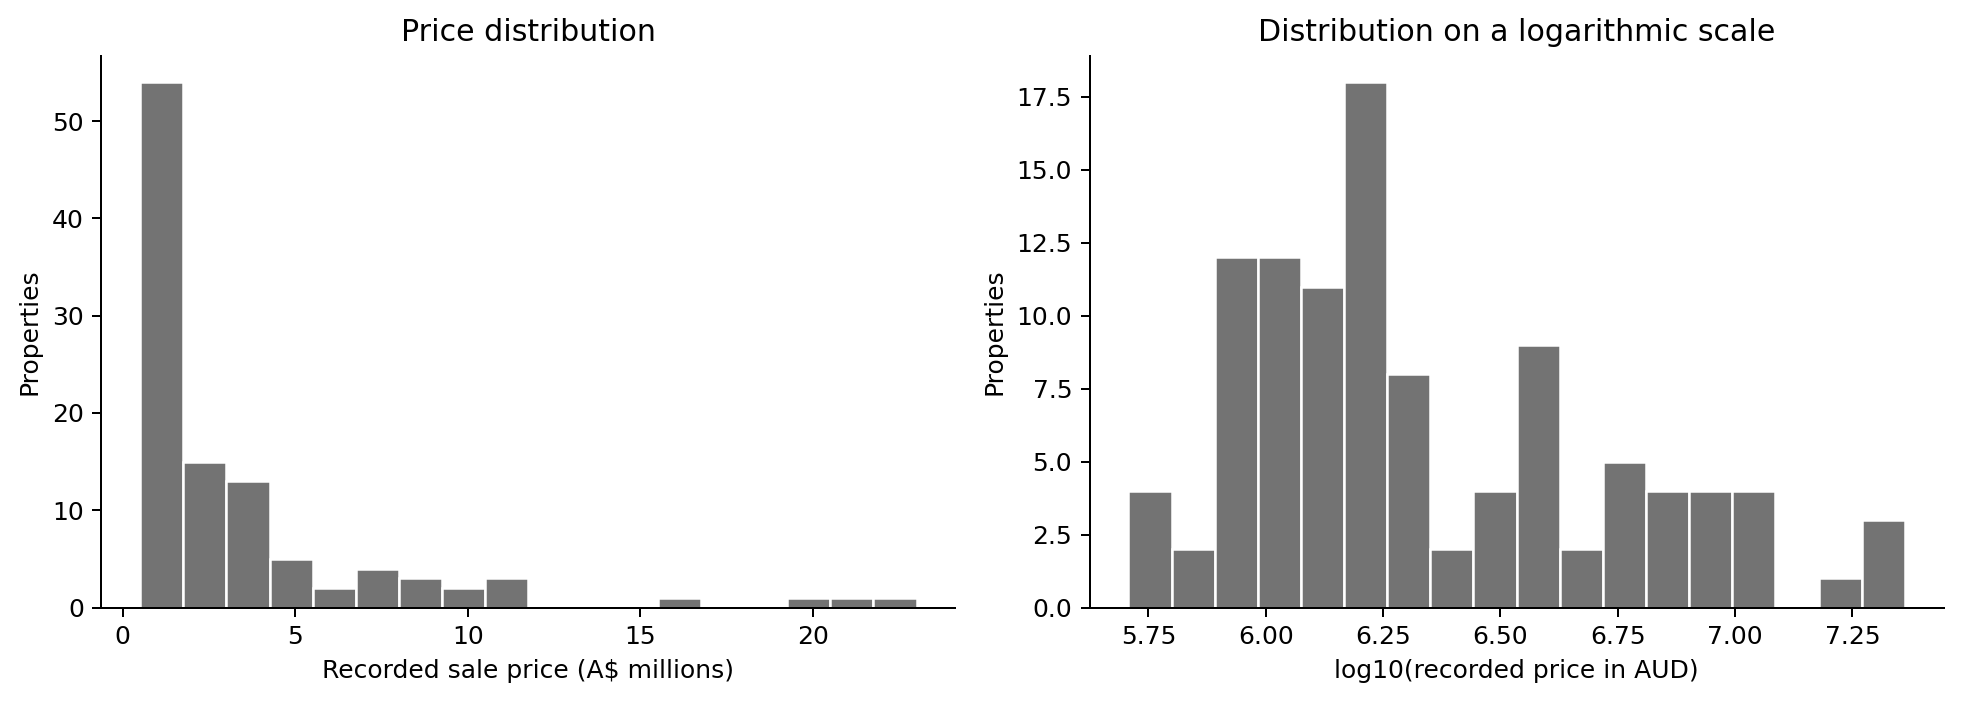

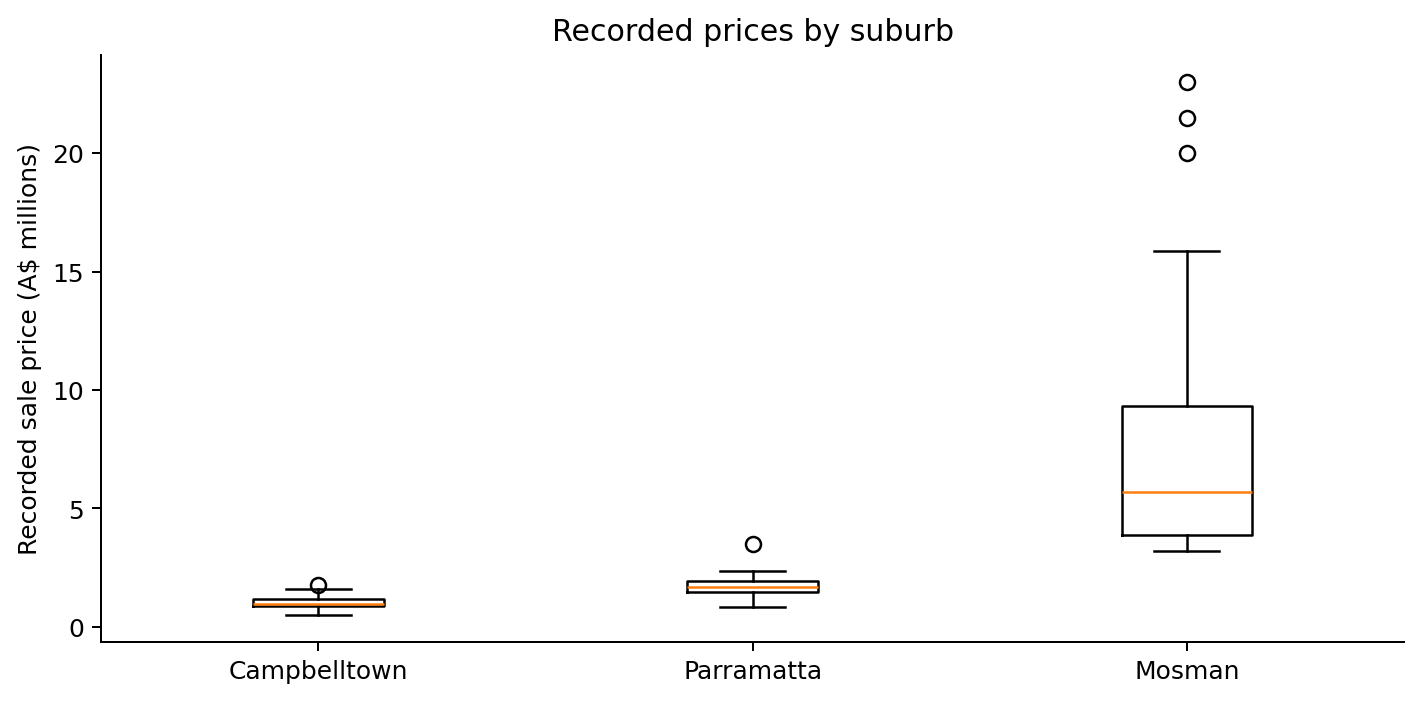

In [6]:
suburb_summary = df.groupby("suburb").agg(
    properties=("sale_price", "size"), median_price_AUD=("sale_price", "median"),
    mean_price_AUD=("sale_price", "mean"), minimum_price_AUD=("sale_price", "min"),
    maximum_price_AUD=("sale_price", "max"), first_sale=("sale_date", "min"),
    last_sale=("sale_date", "max"), missing_land=("land_size_m2", lambda x: x.isna().sum()))
display(suburb_summary)
suburb_summary.to_csv(TABLE_DIR / "suburb_summary.csv")
display(df[["sale_price", "bedrooms", "bathrooms", "parking", "land_size_m2"]].describe())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df.sale_price / 1e6, bins=18, color="0.45", edgecolor="white")
axes[0].set(xlabel="Recorded sale price (A$ millions)", ylabel="Properties", title="Price distribution")
axes[1].hist(np.log10(df.sale_price), bins=18, color="0.45", edgecolor="white")
axes[1].set(xlabel="log10(recorded price in AUD)", ylabel="Properties", title="Distribution on a logarithmic scale")
show_and_save(fig, "01_price_distribution")

fig, ax = plt.subplots(figsize=(8, 4))
ordered_suburbs = ["Campbelltown", "Parramatta", "Mosman"]
ax.boxplot([df.loc[df.suburb.eq(s), "sale_price"] / 1e6 for s in ordered_suburbs], patch_artist=False)
ax.set_xticks([1, 2, 3], ordered_suburbs)
ax.set(ylabel="Recorded sale price (A$ millions)", title="Recorded prices by suburb")
show_and_save(fig, "02_suburb_prices")

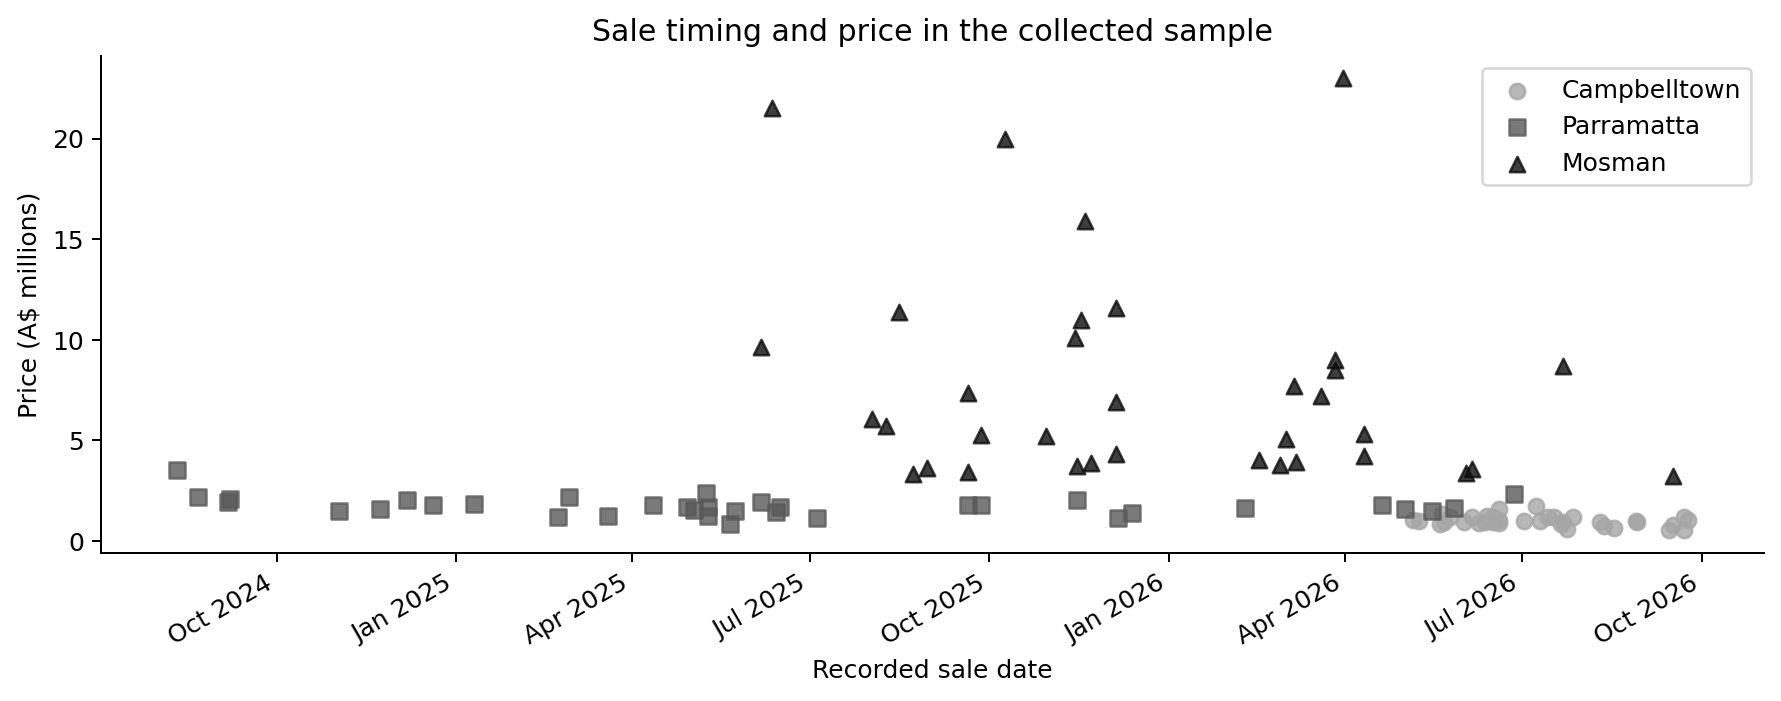

n  median_price_AUD
suburb       quarter                      
Campbelltown 2026Q2   16     1,005,000.000
             2026Q3   19       951,000.000
Mosman       2025Q2    2    15,575,000.000
             2025Q3    8     5,475,000.000
             2025Q4   10     8,500,000.000
             2026Q1    9     7,198,000.000
             2026Q2    4     3,875,000.000
             2026Q3    2     5,950,000.000
Parramatta   2024Q3    4     2,117,500.000
             2024Q4    4     1,680,000.000
             2025Q1    4     1,549,000.000
             2025Q2   11     1,660,000.000
             2025Q3    3     1,771,000.000
             2025Q4    3     1,360,000.000
             2026Q1    1     1,620,000.000
             2026Q2    5     1,610,000.000

These are different properties observed at different times, not repeat sales of the same homes. Sparse quarter counts and changing property mix prevent a strong claim about market growth.

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
for suburb, marker, shade in zip(ordered_suburbs, ["o", "s", "^"], ["0.65", "0.35", "0.05"]):
    part = df[df.suburb.eq(suburb)]
    ax.scatter(pd.to_datetime(part.sale_date), part.sale_price / 1e6,
               label=suburb, marker=marker, color=shade, alpha=0.8, s=38)
ax.set(xlabel="Recorded sale date", ylabel="Price (A$ millions)", title="Sale timing and price in the collected sample")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.legend()
fig.autofmt_xdate()
show_and_save(fig, "03_prices_over_time")
quarterly = (df.assign(quarter=pd.to_datetime(df.sale_date).dt.to_period("Q").astype(str))
               .groupby(["suburb", "quarter"]).agg(n=("sale_price","size"), median_price_AUD=("sale_price","median")))
display(quarterly)
quarterly.to_csv(TABLE_DIR / "quarterly_sample_summary.csv")
display(Markdown("These are different properties observed at different times, not repeat sales of the same homes. Sparse quarter counts and changing property mix prevent a strong claim about market growth."))

No property is removed merely for being expensive or an IQR outlier.


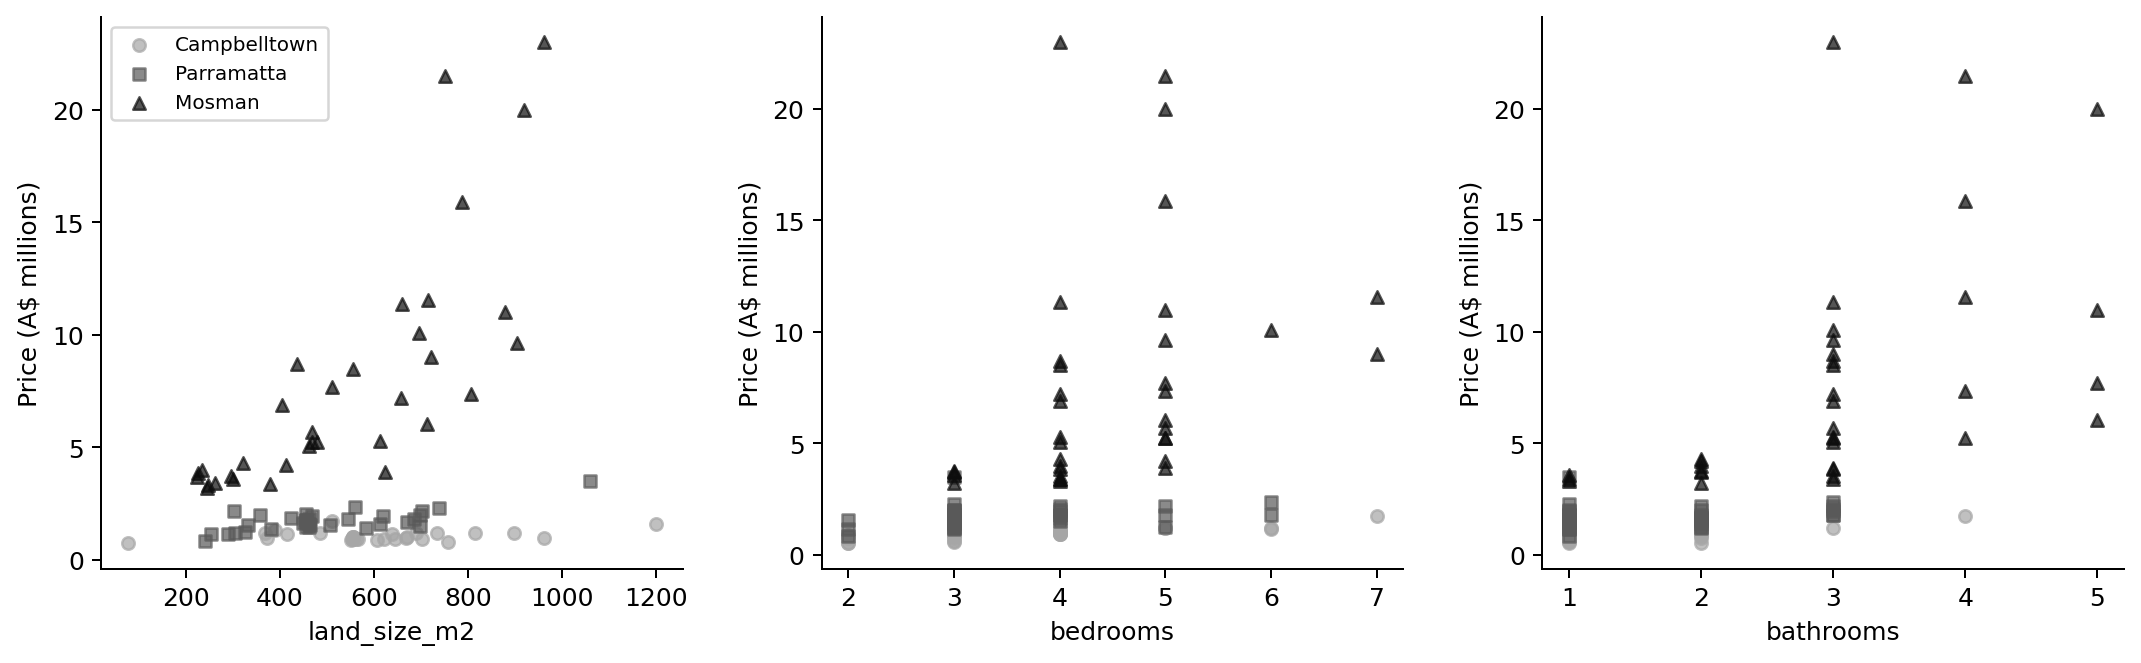

,sale_price,bedrooms,bathrooms,parking,land_size_m2
sale_price,1.000,0.577,0.672,0.317,0.114
bedrooms,0.577,1.000,0.722,0.333,0.212
bathrooms,0.672,0.722,1.000,0.451,0.113
parking,0.317,0.333,0.451,1.000,0.245
land_size_m2,0.114,0.212,0.113,0.245,1.000


,property_id,address,sale_price,bedrooms,bathrooms,land_size_m2
87,88,"28 & 28A Westview Street, Campbelltown NSW 2560",1750000,7,4,510.900
6,7,"17 Morella Road, Mosman NSW 2088",23000000,4,3,961.100
24,25,"40 Stanley Avenue, Mosman NSW 2088",20000000,5,5,920.000
33,34,"37 Carrington Avenue, Mosman NSW 2088",21500000,5,4,751.000
69,70,"171 George Street, Parramatta NSW 2150",3502000,3,1,"1,060.000"


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
for ax, feature in zip(axes, ["land_size_m2", "bedrooms", "bathrooms"]):
    for suburb, marker, shade in zip(ordered_suburbs, ["o", "s", "^"], ["0.65", "0.35", "0.05"]):
        part = df[df.suburb.eq(suburb)]
        ax.scatter(part[feature], part.sale_price / 1e6, label=suburb,
                   marker=marker, color=shade, alpha=0.7, s=25)
    ax.set(xlabel=feature, ylabel="Price (A$ millions)")
axes[0].legend(fontsize=8)
show_and_save(fig, "04_property_features")
numeric_eda = df[["sale_price", "bedrooms", "bathrooms", "parking", "land_size_m2"]]
correlation = numeric_eda.corr(method="spearman")
display(correlation)
correlation.to_csv(TABLE_DIR / "spearman_correlations.csv")

def within_suburb_outliers(group):
    q1, q3 = group.sale_price.quantile([0.25, 0.75])
    iqr = q3 - q1
    return group[(group.sale_price < q1 - 1.5 * iqr) | (group.sale_price > q3 + 1.5 * iqr)]
outliers = pd.concat([within_suburb_outliers(g) for _, g in df.groupby("suburb")])
display(outliers[["property_id", "address", "sale_price", "bedrooms", "bathrooms", "land_size_m2"]])
outliers.to_csv(TABLE_DIR / "descriptive_price_outliers.csv", index=False)
print("No property is removed merely for being expensive or an IQR outlier.")

### What I noticed and which features I used

The median sale prices in this sample are **A$965,000 for Campbelltown**, **A$1,672,000 for Parramatta** and **A$5,700,000 for Mosman**. Mosman also has the widest price range, reaching A$23 million. This made it important to check errors by suburb as well as reporting one overall score.

My starting expectation was that suburb, land size and bathrooms would be the most useful features. Suburb captures broad location differences, land size describes available space, and bathrooms add information about the accommodation. These are reasons to test the features, not evidence that they cause the sale price.

I compared two feature sets:

| Feature set | Inputs |
|---|---|
| Basic | Suburb, bedrooms, bathrooms, parking and land size |
| Engineered | Suburb, bedrooms, bathrooms, parking, log land size, bathrooms per bedroom, sale time and a slash-address indicator |

I used `log1p(land)` to reduce the scale of large land values. The slash-address indicator only records whether the address contains a slash; it does not confirm strata ownership. The sale-time feature describes dates within the sample and does not prove that the model can forecast future prices.

The choice between these feature sets is made inside the inner training folds. I excluded price per square metre and any feature calculated from the target price. I also excluded IDs, source links and full-data suburb mean prices. Postcode repeats the suburb information, and property type is constant in this dataset.


In [9]:
EXPECTED_TOP_VARIABLES = ["suburb", "land_size_m2", "bathrooms"]
EXPECTED_BEST_MODEL = "Random forest"
print("Working feature hypothesis:", EXPECTED_TOP_VARIABLES)
print("Working model hypothesis:", EXPECTED_BEST_MODEL)

Working feature hypothesis: ['suburb', 'land_size_m2', 'bathrooms']
Working model hypothesis: Random forest


## Part 3. Comparing three regression models

I compared Ridge regression, K-nearest neighbours and Random forest because they estimate prices in different ways.

| Model | Why I used it | What could limit it |
|---|---|---|
| Ridge regression | A simple starting model with regularisation to reduce large coefficients. | It can miss more complex relationships between features and price. |
| K-nearest neighbours | Estimates a price from similar properties after scaling the features. | There may be too few genuinely similar properties in a small dataset. |
| Random forest | Combines decision trees and can learn nonlinear relationships. | It can still struggle with a small sample and rare luxury properties. |

Before comparing the results, I expected Random forest to perform best because it can model more complex patterns. I also included two simple baselines: the overall training median price and the training median price for each suburb. These show whether the models improve on a basic price estimate.

### How I evaluated the models

I used five outer cross-validation folds, with seven properties from each suburb in each validation fold. Every model used the same splits. Within each outer training set, I used three inner folds to choose the model settings and feature set. Missing-value imputation and scaling were fitted inside the training folds as part of the pipeline.

All three models were fitted to log-transformed prices to reduce the effect of very large values during training. I converted the predictions back to Australian dollars before calculating the errors. This inverse transformation does not automatically give a bias-corrected estimate of the mean price.

I used **MAE** as the main comparison measure because it shows the average absolute error in dollars. I also reported **RMSE**, which gives more weight to large errors, and **R²**, which compares the predictions with a mean-price reference. R² is not classification accuracy and can be negative.

The fold standard deviation shows how much the results vary across these splits; it is not a confidence interval. This evaluation tests held-out properties from the sampled suburbs, not future sales. I used the outer results to select the model family, so the winning score is not from a separate test set untouched by model selection.


In [10]:
# Shared transformations are exported with the saved model.
UTILS_SOURCE = '"""Shared transformations for the SIT307 housing notebook and application."""\nimport numpy as np\nimport pandas as pd\nfrom sklearn.base import BaseEstimator, TransformerMixin\nfrom sklearn.compose import ColumnTransformer, TransformedTargetRegressor, make_column_selector\nfrom sklearn.ensemble import RandomForestRegressor\nfrom sklearn.impute import SimpleImputer\nfrom sklearn.linear_model import Ridge\nfrom sklearn.neighbors import KNeighborsRegressor\nfrom sklearn.pipeline import Pipeline\nfrom sklearn.preprocessing import OneHotEncoder, StandardScaler\n\nBASIC_FEATURES = ["suburb", "bedrooms", "bathrooms", "parking", "land_size_m2"]\nRAW_FEATURES = ["suburb", "bedrooms", "bathrooms", "parking", "land_size_m2",\n                "sale_date", "unit_style_address"]\nMODEL_NAMES = ["Ridge regression", "K-nearest neighbours", "Random forest"]\n\nclass PropertyFeatures(BaseEstimator, TransformerMixin):\n    """Row-wise, target-free features; learned preprocessing stays in the pipeline."""\n    def __init__(self, feature_set="basic"):\n        self.feature_set = feature_set\n\n    def fit(self, X, y=None):\n        self.n_features_in_ = X.shape[1]\n        self.feature_names_in_ = np.asarray(X.columns, dtype=object)\n        return self\n\n    def transform(self, X):\n        d = X.copy()\n        out = d[["suburb", "bedrooms", "bathrooms", "parking"]].copy()\n        for c in ["bedrooms", "bathrooms", "parking"]:\n            out[c] = pd.to_numeric(out[c], errors="raise").astype(float)\n        land = pd.to_numeric(d["land_size_m2"], errors="raise").astype(float)\n        if self.feature_set == "basic":\n            out["land_size_m2"] = land\n        elif self.feature_set == "engineered":\n            out["log_land_size"] = np.log1p(land)\n            out["bathrooms_per_bedroom"] = out["bathrooms"] / out["bedrooms"]\n            # Fixed origin: no statistic is learned from validation dates.\n            out["sale_time_years"] = (\n                pd.to_datetime(d["sale_date"]) - pd.Timestamp("2024-01-01")\n            ).dt.days / 365.25\n            out["unit_style_address"] = pd.to_numeric(d["unit_style_address"]).astype(float)\n        else:\n            raise ValueError("feature_set must be \'basic\' or \'engineered\'")\n        return out\n\ndef make_estimator(name, seed=42):\n    estimators = {\n        "Ridge regression": Ridge(),\n        "K-nearest neighbours": KNeighborsRegressor(),\n        "Random forest": RandomForestRegressor(n_estimators=120, random_state=seed, n_jobs=1),\n    }\n    preprocess = ColumnTransformer([\n        ("numeric", Pipeline([\n            ("imputer", SimpleImputer(strategy="median", add_indicator=True, keep_empty_features=True)),\n            ("scale", StandardScaler()),\n        ]), make_column_selector(dtype_include=np.number)),\n        ("suburb", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ["suburb"]),\n    ])\n    pipe = Pipeline([\n        ("features", PropertyFeatures()),\n        ("preprocess", preprocess),\n        ("model", estimators[name]),\n    ])\n    # Train on log prices; predict and evaluate in the original AUD scale.\n    return TransformedTargetRegressor(regressor=pipe, func=np.log1p, inverse_func=np.expm1)\n\ndef parameter_grid(name):\n    common = {"regressor__features__feature_set": ["basic", "engineered"]}\n    grids = {\n        "Ridge regression": {"regressor__model__alpha": [0.1, 1.0, 10.0, 100.0]},\n        "K-nearest neighbours": {\n            "regressor__model__n_neighbors": [3, 5, 9],\n            "regressor__model__weights": ["uniform", "distance"],\n        },\n        "Random forest": {\n            "regressor__model__max_depth": [4, None],\n            "regressor__model__min_samples_leaf": [2, 4],\n        },\n    }\n    return {**common, **grids[name]}\n\ndef required_input_features(metadata):\n    """Only request variables used by the selected feature transformation."""\n    return BASIC_FEATURES if metadata["feature_set"] == "basic" else RAW_FEATURES\n\n\ndef validate_inputs(frame, metadata):\n    """Validate predictive inputs and supply unused compatibility columns internally."""\n    required = required_input_features(metadata)\n    missing = sorted(set(required) - set(frame.columns))\n    if missing:\n        raise ValueError("Missing columns: " + ", ".join(missing))\n    d = frame[required].copy()\n    if d.empty:\n        raise ValueError("The input contains no properties.")\n    if metadata["feature_set"] == "basic":\n        # These fields are part of the training schema but ignored by basic Ridge.\n        # Older CSVs remain accepted; their redundant fields cannot affect predictions.\n        d["sale_date"] = metadata["date_max"]\n        d["unit_style_address"] = 0\n    d["suburb"] = d["suburb"].astype(str).str.strip()\n    unknown = sorted(set(d["suburb"]) - set(metadata["suburbs"]))\n    if unknown:\n        raise ValueError("Unsupported suburb(s): " + ", ".join(unknown))\n    for c in ["bedrooms", "bathrooms", "parking", "land_size_m2", "unit_style_address"]:\n        d[c] = pd.to_numeric(d[c], errors="raise")\n        observed = d[c].dropna().to_numpy(dtype=float)\n        if not np.isfinite(observed).all():\n            raise ValueError(f"{c}: values must be finite.")\n    for c in ["bedrooms", "bathrooms", "parking", "unit_style_address"]:\n        if d[c].isna().any() or (d[c] % 1 != 0).any():\n            raise ValueError(f"{c}: enter a whole number for every property.")\n    if (d["bedrooms"] < 1).any() or (d["bathrooms"] < 1).any() or (d["parking"] < 0).any():\n        raise ValueError("Bedrooms and bathrooms must be positive; parking can be zero.")\n    if (~d["unit_style_address"].isin([0, 1])).any():\n        raise ValueError("unit_style_address must be 0 or 1.")\n    if (d["land_size_m2"].dropna() <= 0).any():\n        raise ValueError("Land size must be positive or blank when unknown.")\n    dates = pd.to_datetime(d["sale_date"], errors="coerce")\n    if dates.isna().any():\n        raise ValueError("Enter valid dates in YYYY-MM-DD format.")\n    d["sale_date"] = dates.dt.strftime("%Y-%m-%d")\n    return d[RAW_FEATURES]\n\n\ndef input_warnings(d, metadata):\n    messages = []\n    if d["land_size_m2"].isna().any():\n        messages.append("Unknown land sizes will use the model\'s training-data imputation.")\n    for c, limits in metadata["numeric_ranges"].items():\n        if ((d[c] < limits["min"]) | (d[c] > limits["max"])).any():\n            messages.append(f"{c}: some values are outside the observed training range.")\n    if metadata["feature_set"] != "basic":\n        dates = pd.to_datetime(d["sale_date"])\n        if ((dates < pd.Timestamp(metadata["date_min"])) | (dates > pd.Timestamp(metadata["date_max"]))).any():\n            messages.append("Some dates are outside the training period; future-market performance is untested.")\n    return messages\n\n\ndef predict_properties(frame, model, metadata):\n    """Use the same validated inference path for single-property and CSV requests."""\n    clean = validate_inputs(frame, metadata)\n    predicted = np.asarray(model.predict(clean), dtype=float)\n    if not np.isfinite(predicted).all() or (predicted <= 0).any():\n        raise ValueError("The model could not return a finite positive price for these inputs.")\n    result = clean[required_input_features(metadata)].copy()\n    result["predicted_sale_price_aud"] = np.round(predicted, 0)\n    return result, input_warnings(clean, metadata)\n'
(APP_DIR / "housing_utils.py").write_text(UTILS_SOURCE, encoding="utf-8")
sys.path.insert(0, str(APP_DIR.resolve()))
import importlib
importlib.invalidate_caches()
import housing_utils
importlib.reload(housing_utils)
from housing_utils import RAW_FEATURES, MODEL_NAMES, PropertyFeatures, make_estimator, parameter_grid

X = df[RAW_FEATURES].copy()
y = df["sale_price"].astype(float).copy()
assert "sale_price" not in X and "reported_land_size_m2" not in X
outer_cv = StratifiedKFold(n_splits=OUTER_FOLDS, shuffle=True, random_state=SEED)
outer_splits = list(outer_cv.split(X, df.suburb))
fold_assignment = np.zeros(len(df), dtype=int)
for fold, (train_idx, valid_idx) in enumerate(outer_splits, 1):
    assert not set(train_idx) & set(valid_idx)
    fold_assignment[valid_idx] = fold
assert (fold_assignment > 0).all()
fold_audit = pd.crosstab(pd.Series(fold_assignment, name="outer_fold"), df.suburb)
display(fold_audit)
fold_audit.to_csv(TABLE_DIR / "outer_fold_suburb_counts.csv")
print("Basic feature preview:")
display(PropertyFeatures("basic").fit_transform(X).head(3))
print("Engineered feature preview (missing values are still missing):")
display(PropertyFeatures("engineered").fit_transform(X).head(3))


Basic feature preview:
Engineered feature preview (missing values are still missing):


suburb,Campbelltown,Mosman,Parramatta
outer_fold,,,
1,7,7,7
2,7,7,7
3,7,7,7
4,7,7,7
5,7,7,7


,suburb,bedrooms,bathrooms,parking,land_size_m2
0,Mosman,3.000,2.000,2.000,245.000
1,Mosman,4.000,3.000,2.000,437.000
2,Mosman,4.000,3.000,0.000,NaN


,suburb,bedrooms,bathrooms,parking,log_land_size,bathrooms_per_bedroom,sale_time_years,unit_style_address
0,Mosman,3.000,2.000,2.000,5.505,0.667,2.708,0.000
1,Mosman,4.000,3.000,2.000,6.082,0.750,2.554,0.000
2,Mosman,4.000,3.000,0.000,NaN,0.750,2.426,0.000


### Training and tuning

The next cell trains each model on the outer training folds and predicts the properties left out of each fold. I kept the parameter grids small because there are only 105 records. I also kept the same seed and splits throughout the comparison.

The progress messages show which model and fold have finished. The saved predictions allow each property to be assessed using a model that did not train on that property.


In [11]:
fold_rows, tuning_rows, feature_rows = [], [], []
oof_predictions = {name: np.full(len(df), np.nan) for name in MODEL_NAMES + ["Overall median", "Suburb median"]}
outer_models = {name: [] for name in MODEL_NAMES}
training_started = time.perf_counter()

for fold, (train_idx, valid_idx) in enumerate(outer_splits, 1):
    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
    inner_cv = StratifiedKFold(n_splits=INNER_FOLDS, shuffle=True, random_state=SEED + fold)
    inner_splits = list(inner_cv.split(X_train, X_train.suburb))
    for inner_train, inner_valid in inner_splits:
        assert not set(train_idx[inner_train]) & set(valid_idx)
        assert not set(inner_train) & set(inner_valid)

    median_price = float(y_train.median())
    suburb_medians = pd.DataFrame({"suburb": X_train.suburb, "price": y_train}).groupby("suburb").price.median()
    baseline_predictions = {
        "Overall median": (np.full(len(train_idx), median_price), np.full(len(valid_idx), median_price)),
        "Suburb median": (X_train.suburb.map(suburb_medians).to_numpy(), X_valid.suburb.map(suburb_medians).to_numpy()),
    }
    for name, (train_pred, valid_pred) in baseline_predictions.items():
        metrics = score_predictions(y_valid, valid_pred)
        oof_predictions[name][valid_idx] = valid_pred
        fold_rows.append({"model": name, "fold": fold, **metrics,
                          "train_MAE_AUD": mean_absolute_error(y_train, train_pred),
                          "best_feature_set": "baseline", "inner_MAE_AUD": np.nan})

    for name in MODEL_NAMES:
        search = GridSearchCV(make_estimator(name, SEED), parameter_grid(name),
                              scoring="neg_mean_absolute_error", cv=inner_splits,
                              n_jobs=CV_JOBS, refit=True, error_score="raise")
        search.fit(X_train, y_train)
        valid_pred = search.predict(X_valid)
        train_pred = search.predict(X_train)
        oof_predictions[name][valid_idx] = valid_pred
        outer_models[name].append(search.best_estimator_)
        metrics = score_predictions(y_valid, valid_pred)
        chosen_features = search.best_params_["regressor__features__feature_set"]
        fold_rows.append({"model": name, "fold": fold, **metrics,
                          "train_MAE_AUD": mean_absolute_error(y_train, train_pred),
                          "best_feature_set": chosen_features, "inner_MAE_AUD": -search.best_score_})
        for params, inner_score in zip(search.cv_results_["params"], search.cv_results_["mean_test_score"]):
            tuning_rows.append({"model": name, "fold": fold,
                                "feature_set": params["regressor__features__feature_set"],
                                "inner_MAE_AUD": -float(inner_score), "parameters": json.dumps(params)})
        # Fixed-feature ablation: tune within the same training folds, then evaluate
        # each feature set on the held-out outer fold. Do not tune on these scores.
        for feature_set in ["basic", "engineered"]:
            indices = [i for i,p in enumerate(search.cv_results_["params"])
                       if p["regressor__features__feature_set"] == feature_set]
            best_i = max(indices, key=lambda i: search.cv_results_["mean_test_score"][i])
            params = search.cv_results_["params"][best_i]
            alternative = clone(search.estimator).set_params(**params).fit(X_train, y_train)
            feature_rows.append({"model": name, "feature_set": feature_set, "fold": fold,
                                 **score_predictions(y_valid, alternative.predict(X_valid))})
        print(f"Fold {fold}/{OUTER_FOLDS} | {name:20s} | MAE A${metrics['MAE_AUD']:,.0f} | {chosen_features}")

fold_results = pd.DataFrame(fold_rows)
tuning_results = pd.DataFrame(tuning_rows)
feature_results = pd.DataFrame(feature_rows)
for name, predictions in oof_predictions.items():
    assert np.isfinite(predictions).all(), f"Missing out-of-fold predictions for {name}"
fold_results.to_csv(TABLE_DIR / "fold_results.csv", index=False)
tuning_results.to_csv(TABLE_DIR / "inner_tuning_results.csv", index=False)
feature_results.to_csv(TABLE_DIR / "feature_set_fold_results.csv", index=False)
print(f"Completed in {time.perf_counter() - training_started:.1f} seconds.")

Fold 1/5 | Ridge regression     | MAE A$572,028 | basic
Fold 1/5 | K-nearest neighbours | MAE A$622,754 | basic
Fold 1/5 | Random forest        | MAE A$550,119 | basic
Fold 2/5 | Ridge regression     | MAE A$811,292 | basic
Fold 2/5 | K-nearest neighbours | MAE A$1,336,435 | basic
Fold 2/5 | Random forest        | MAE A$1,079,685 | basic
Fold 3/5 | Ridge regression     | MAE A$1,683,625 | basic
Fold 3/5 | K-nearest neighbours | MAE A$1,799,907 | basic
Fold 3/5 | Random forest        | MAE A$1,498,622 | engineered
Fold 4/5 | Ridge regression     | MAE A$646,489 | basic
Fold 4/5 | K-nearest neighbours | MAE A$1,119,710 | basic
Fold 4/5 | Random forest        | MAE A$975,081 | basic
Fold 5/5 | Ridge regression     | MAE A$775,600 | basic
Fold 5/5 | K-nearest neighbours | MAE A$1,228,715 | basic
Fold 5/5 | Random forest        | MAE A$884,939 | basic
Completed in 14.8 seconds.


**Outer-fold mean and standard deviation:**

,MAE_mean_AUD,MAE_sd_AUD,RMSE_mean_AUD,RMSE_sd_AUD,R2_mean,R2_sd,train_MAE_mean_AUD,validation_minus_train_MAE_AUD
model,,,,,,,,
Ridge regression,"897,806.819","449,783.850","2,000,343.741","1,282,856.376",0.744,0.141,"833,514.340","64,292.479"
Random forest,"997,689.201","343,220.062","2,176,277.567","967,750.246",0.625,0.257,"700,411.241","297,277.960"
K-nearest neighbours,"1,221,504.163","423,283.252","2,544,033.921","944,344.435",0.531,0.226,"392,857.806","828,646.357"
Suburb median,"1,452,605.286","605,081.245","2,952,009.908","1,651,185.823",0.475,0.189,"1,367,231.476","85,373.810"
Overall median,"2,353,804.238","785,537.085","4,325,724.844","1,758,383.972",-0.198,0.045,"2,350,256.619","3,547.619"


**Pooled out-of-fold metrics (all 105 held-out predictions):**

,MAE_AUD,RMSE_AUD,R2
model,,,
Ridge regression,"897,806.819","2,306,068.400",0.706
Random forest,"997,689.201","2,342,096.599",0.697
K-nearest neighbours,"1,221,504.163","2,680,585.331",0.603
Suburb median,"1,452,605.286","3,300,832.348",0.398
Overall median,"2,353,804.238","4,602,762.950",-0.171


The best of the three regression models by mean outer-fold MAE is **Ridge regression** (A$897,807). It does not match the initial expectation of Random forest. Its MAE change relative to the suburb-median baseline is **+38.2% improvement**. The model adds predictive value over this baseline in these folds. The three-model comparison determines which fitted regression model is exported. A final independent or future-period test would be needed for a stronger deployment claim.

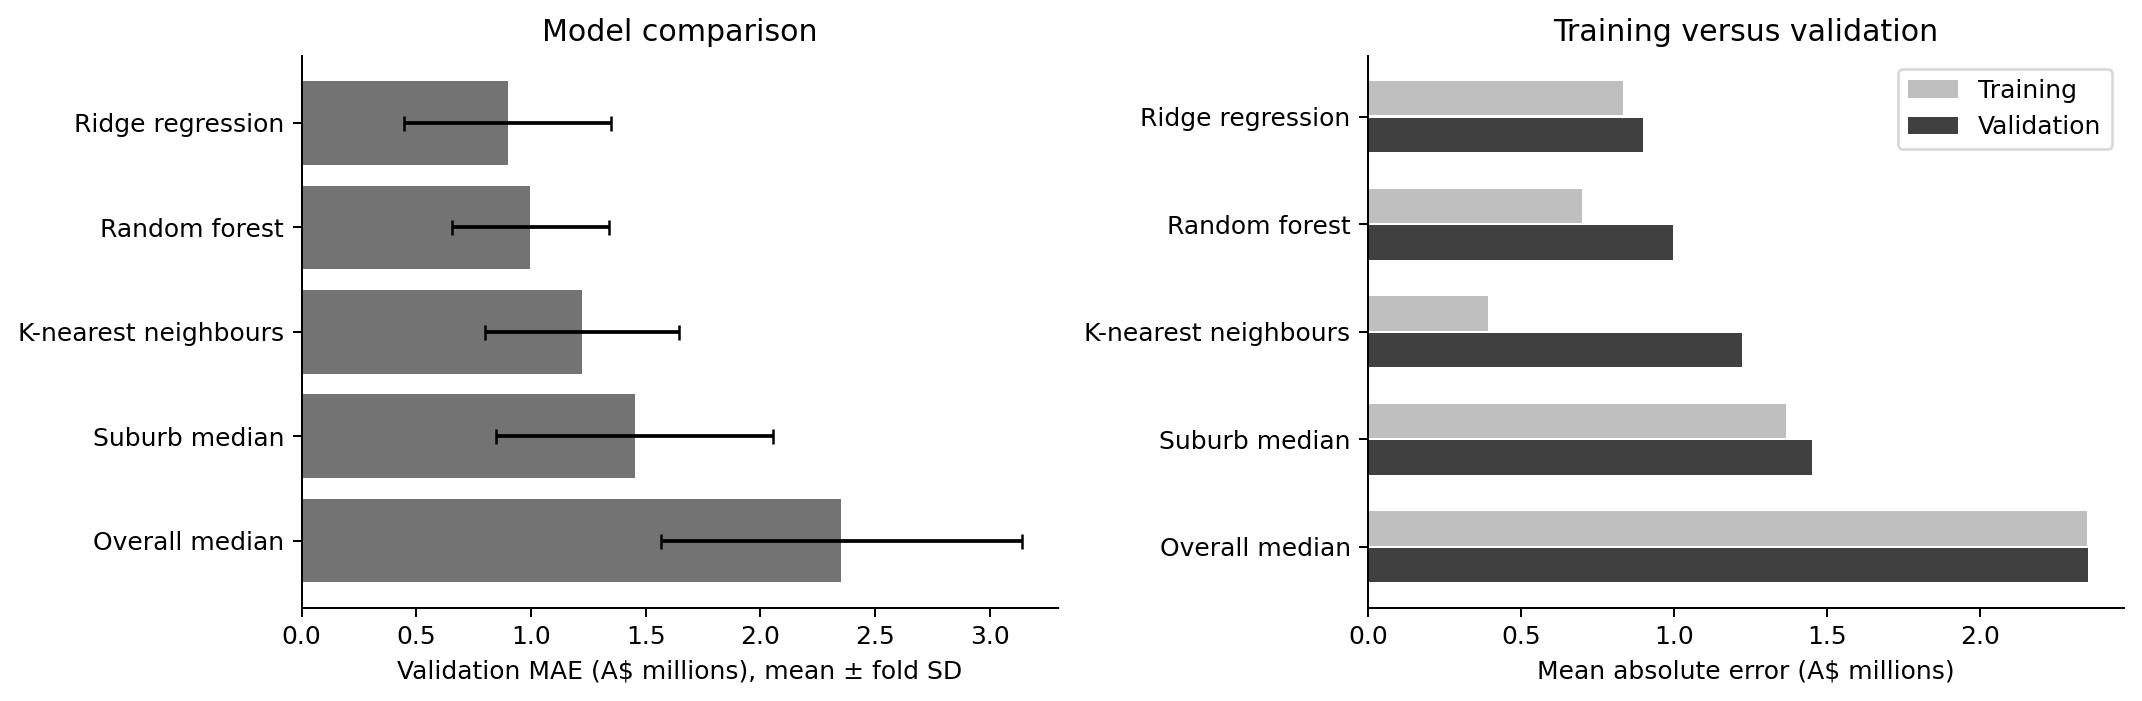

In [12]:
summary = fold_results.groupby("model").agg(
    MAE_mean_AUD=("MAE_AUD", "mean"), MAE_sd_AUD=("MAE_AUD", "std"),
    RMSE_mean_AUD=("RMSE_AUD", "mean"), RMSE_sd_AUD=("RMSE_AUD", "std"),
    R2_mean=("R2", "mean"), R2_sd=("R2", "std"),
    train_MAE_mean_AUD=("train_MAE_AUD", "mean"))
summary["validation_minus_train_MAE_AUD"] = summary.MAE_mean_AUD - summary.train_MAE_mean_AUD
summary = summary.sort_values("MAE_mean_AUD")
pooled = pd.DataFrame([{"model": name, **score_predictions(y, pred)}
                       for name, pred in oof_predictions.items()]).set_index("model").sort_values("MAE_AUD")
display(Markdown("**Outer-fold mean and standard deviation:**"))
display(summary)
display(Markdown("**Pooled out-of-fold metrics (all 105 held-out predictions):**"))
display(pooled)
summary.to_csv(TABLE_DIR / "model_comparison.csv")
pooled.to_csv(TABLE_DIR / "pooled_oof_metrics.csv")
winner = summary.loc[MODEL_NAMES].MAE_mean_AUD.idxmin()
baseline_mae = summary.loc["Suburb median", "MAE_mean_AUD"]
winner_mae = summary.loc[winner, "MAE_mean_AUD"]
improvement_pct = 100 * (baseline_mae - winner_mae) / baseline_mae
matches_expectation = winner == EXPECTED_BEST_MODEL
display(Markdown(
    f"The best of the three regression models by mean outer-fold MAE is **{winner}** "
    f"(A${winner_mae:,.0f}). It {'matches' if matches_expectation else 'does not match'} "
    f"the initial expectation of {EXPECTED_BEST_MODEL}. Its MAE change relative to the suburb-median "
    f"baseline is **{improvement_pct:+.1f}% improvement**. "
    + ("The model adds predictive value over this baseline in these folds. " if improvement_pct > 0
       else "The simple suburb baseline is competitive or better; deploying a complex model is not justified by MAE alone. ")
    + "The three-model comparison determines which fitted regression model is exported. "
      "A final independent or future-period test would be needed for a stronger deployment claim."
))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pos = np.arange(len(summary))
axes[0].barh(pos, summary.MAE_mean_AUD / 1e6, xerr=summary.MAE_sd_AUD / 1e6,
             color="0.45", capsize=3)
axes[0].set_yticks(pos, summary.index)
axes[0].invert_yaxis()
axes[0].set(xlabel="Validation MAE (A$ millions), mean ± fold SD", title="Model comparison")
axes[1].barh(pos - 0.17, summary.train_MAE_mean_AUD / 1e6, height=0.32, color="0.75", label="Training")
axes[1].barh(pos + 0.17, summary.MAE_mean_AUD / 1e6, height=0.32, color="0.25", label="Validation")
axes[1].set_yticks(pos, summary.index)
axes[1].invert_yaxis()
axes[1].set(xlabel="Mean absolute error (A$ millions)", title="Training versus validation")
axes[1].legend()
show_and_save(fig, "05_model_comparison")

### What the model results showed

Ridge regression gave the lowest MAE at **A$897,807**, followed by Random forest at **A$997,689** and K-nearest neighbours at **A$1,221,504**. Ridge's pooled RMSE was **A$2,306,068** and its pooled R² was **0.706**. These scores use the saved out-of-fold predictions. Pooled RMSE and R² are calculated from all those predictions together, so they differ from the averages of the individual fold scores.

All three models improved on the suburb-median baseline, which had an MAE of **A$1,452,605**. However, the remaining errors are still substantial. I would not describe an R² of 0.706 as 70.6% accuracy.

Ridge also had the smallest gap between average training and validation MAE among the three models, at about **A$64,292**. The gaps were about **A$297,278** for Random forest and **A$828,646** for K-nearest neighbours. The larger KNN gap suggests weaker generalisation in this comparison, although the gap alone does not prove a single cause.

### Checking whether feature engineering helped

I compared the basic and engineered features using the same outer folds, with model settings tuned separately within the training data. In the table below, a positive `MAE_reduction_AUD` means the engineered features reduced the error. A negative value means the error increased.


In [13]:
feature_comparison = feature_results.groupby(["model", "feature_set"]).MAE_AUD.mean().unstack()
feature_comparison["MAE_reduction_AUD"] = feature_comparison["basic"] - feature_comparison["engineered"]
display(feature_comparison)
feature_comparison.to_csv(TABLE_DIR / "feature_engineering_comparison.csv")
selected_settings = []
for name in MODEL_NAMES:
    for fold, fitted in enumerate(outer_models[name], 1):
        selected_settings.append({"model": name, "fold": fold,
             "feature_set": fitted.regressor_.named_steps["features"].feature_set,
             "model_settings": str(fitted.regressor_.named_steps["model"])})
display(pd.DataFrame(selected_settings))
pd.DataFrame(selected_settings).to_csv(TABLE_DIR / "selected_outer_settings.csv", index=False)

comparison_sentences = []
for name in MODEL_NAMES:
    row = summary.loc[name]
    delta = feature_comparison.loc[name, "MAE_reduction_AUD"]
    comparison_sentences.append(
        f"- **{name}:** training MAE A${row.train_MAE_mean_AUD:,.0f}; validation MAE "
        f"A${row.MAE_mean_AUD:,.0f}; gap A${row.validation_minus_train_MAE_AUD:,.0f}. "
        f"Engineered features {'reduced' if delta > 0 else 'increased'} mean validation MAE "
        f"by A${abs(delta):,.0f}."
    )
display(Markdown("\n".join(comparison_sentences)))

feature_set,basic,engineered,MAE_reduction_AUD
model,,,
K-nearest neighbours,"1,221,504.163","1,332,206.192","-110,702.030"
Random forest,"972,969.128","1,021,073.399","-48,104.272"
Ridge regression,"897,806.819","946,872.486","-49,065.667"


,model,fold,feature_set,model_settings
0,Ridge regression,1,basic,Ridge(alpha=0.1)
1,Ridge regression,2,basic,Ridge(alpha=0.1)
2,Ridge regression,3,basic,Ridge(alpha=0.1)
3,Ridge regression,4,basic,Ridge(alpha=0.1)
4,Ridge regression,5,basic,Ridge(alpha=0.1)
5,K-nearest neighbours,1,basic,KNeighborsRegressor(n_neighbors=3)
6,K-nearest neighbours,2,basic,"KNeighborsRegressor(n_neighbors=9, weights='distance')"
7,K-nearest neighbours,3,basic,"KNeighborsRegressor(n_neighbors=3, weights='distance')"
8,K-nearest neighbours,4,basic,KNeighborsRegressor(n_neighbors=3)
9,K-nearest neighbours,5,basic,"KNeighborsRegressor(n_neighbors=3, weights='distance')"


- **Ridge regression:** training MAE A$833,514; validation MAE A$897,807; gap A$64,292. Engineered features increased mean validation MAE by A$49,066.
- **K-nearest neighbours:** training MAE A$392,858; validation MAE A$1,221,504; gap A$828,646. Engineered features increased mean validation MAE by A$110,702.
- **Random forest:** training MAE A$700,411; validation MAE A$997,689; gap A$297,278. Engineered features increased mean validation MAE by A$48,104.

### My feature-engineering result

The engineered features increased average MAE by about **A$49,066 for Ridge**, **A$110,702 for K-nearest neighbours** and **A$48,104 for Random forest**. Adding the extra columns did not improve these comparisons.

The basic-only Random forest result is slightly different from the main model comparison because the main procedure chose between basic and engineered features inside each training fold. It chose engineered features in one outer fold. I kept these two comparisons separate when interpreting the results.


,mean,std
feature,,
suburb,"1,602,709.863","220,409.856"
land_size_m2,"528,407.752","318,808.913"
bathrooms,"204,038.825","155,812.676"
bedrooms,"36,497.481","39,527.593"
parking,"10,747.566","12,816.264"
sale_date,0.000,0.000
unit_style_address,0.000,0.000


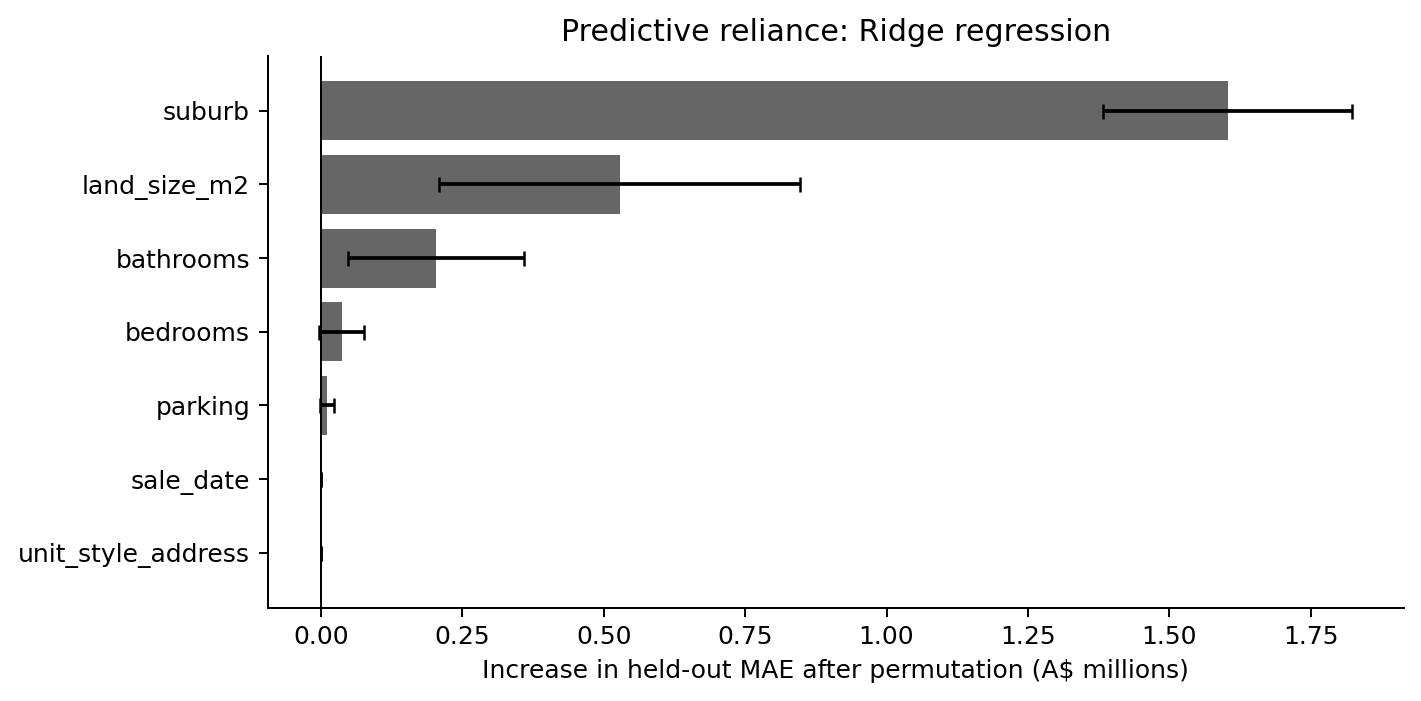

Initial top-three hypothesis: **suburb, land_size_m2, bathrooms**. Observed top three by mean permutation effect: **suburb, land_size_m2, bathrooms**. Correlated predictors can share importance; this is predictive reliance, not a causal effect. Negative effects are possible with small validation samples. Unused inputs have zero effect.

In [14]:
# Held-out permutation importance passes raw inputs through the complete pipeline.
# When land or bedrooms are permuted, dependent engineered features are rebuilt.
importance_rows = []
for fold, (_, valid_idx) in enumerate(outer_splits, 1):
    result = permutation_importance(outer_models[winner][fold-1], X.iloc[valid_idx], y.iloc[valid_idx],
                                    scoring="neg_mean_absolute_error", n_repeats=5,
                                    random_state=SEED + fold, n_jobs=1)
    for feature, value in zip(X.columns, result.importances_mean):
        importance_rows.append({"fold": fold, "feature": feature, "MAE_increase_AUD": value})
importance = pd.DataFrame(importance_rows).groupby("feature").MAE_increase_AUD.agg(["mean", "std"]).sort_values("mean", ascending=False)
display(importance)
importance.to_csv(TABLE_DIR / "heldout_permutation_importance.csv")
fig, ax = plt.subplots(figsize=(8, 4))
imp_plot = importance.iloc[::-1]
ax.barh(imp_plot.index, imp_plot["mean"] / 1e6, xerr=imp_plot["std"] / 1e6, color="0.4", capsize=3)
ax.axvline(0, color="black", linewidth=0.8)
ax.set(xlabel="Increase in held-out MAE after permutation (A$ millions)", title=f"Predictive reliance: {winner}")
show_and_save(fig, "06_permutation_importance")
observed_top = importance.index[:3].tolist()
display(Markdown(f"Initial top-three hypothesis: **{', '.join(EXPECTED_TOP_VARIABLES)}**. "
                 f"Observed top three by mean permutation effect: **{', '.join(observed_top)}**. "
                 "Correlated predictors can share importance; this is predictive reliance, not a causal effect. "
                 "Negative effects are possible with small validation samples. Unused inputs have zero effect."))

### Which features mattered most?

The held-out permutation check gave the largest increase in error when suburb was shuffled, followed by land size and bathrooms. This supports my initial expectation about the most useful inputs for this dataset. Bedrooms and parking had smaller effects in this check.

Permutation importance shows how much the fitted model relies on an input; it does not show that the input causes a price change. Sale date and the slash-address indicator had zero effect here because the selected basic Ridge models do not use them.


## Part 4. Looking at the five largest prediction errors

I selected the five properties with the largest absolute errors from the out-of-fold predictions. Each property was predicted by a model that had not trained on it. I did not use the final model's training predictions for this investigation.

All five cases are in Mosman. Four were underpredicted and one was overpredicted. I compared their recorded features, available training examples and listing descriptions to see what information the models might be missing.

The signed error is **predicted price minus actual price**. A negative value means the prediction was too low, while a positive value means it was too high. The listing details below give possible explanations, but they do not prove what caused each error.


,property_id,address,sale_date,sale_price,predicted_sale_price,signed_error_AUD,absolute_error_AUD,absolute_percentage_error,bedrooms,bathrooms,parking,land_size_m2,outer_fold
6,7,"17 Morella Road, Mosman NSW 2088",2026-03-31,23000000,"8,900,513.844","-14,099,486.156","14,099,486.156",61.302,4,3,2,961.100,3
33,34,"37 Carrington Avenue, Mosman NSW 2088",2025-06-12,21500000,"8,742,304.262","-12,757,695.738","12,757,695.738",59.338,5,4,2,751.000,3
24,25,"40 Stanley Avenue, Mosman NSW 2088",2025-10-09,20000000,"13,308,419.704","-6,691,580.296","6,691,580.296",33.458,5,5,2,920.000,5
19,20,"15 Balmoral Avenue, Mosman NSW 2088",2025-11-19,15880000,"9,801,815.806","-6,078,184.194","6,078,184.194",38.276,5,4,2,788.000,1
32,33,"16 Upper Spit Road, Mosman NSW 2088",2025-08-02,6050000,"10,951,916.601","4,901,916.601","4,901,916.601",81.023,5,5,2,712.000,2


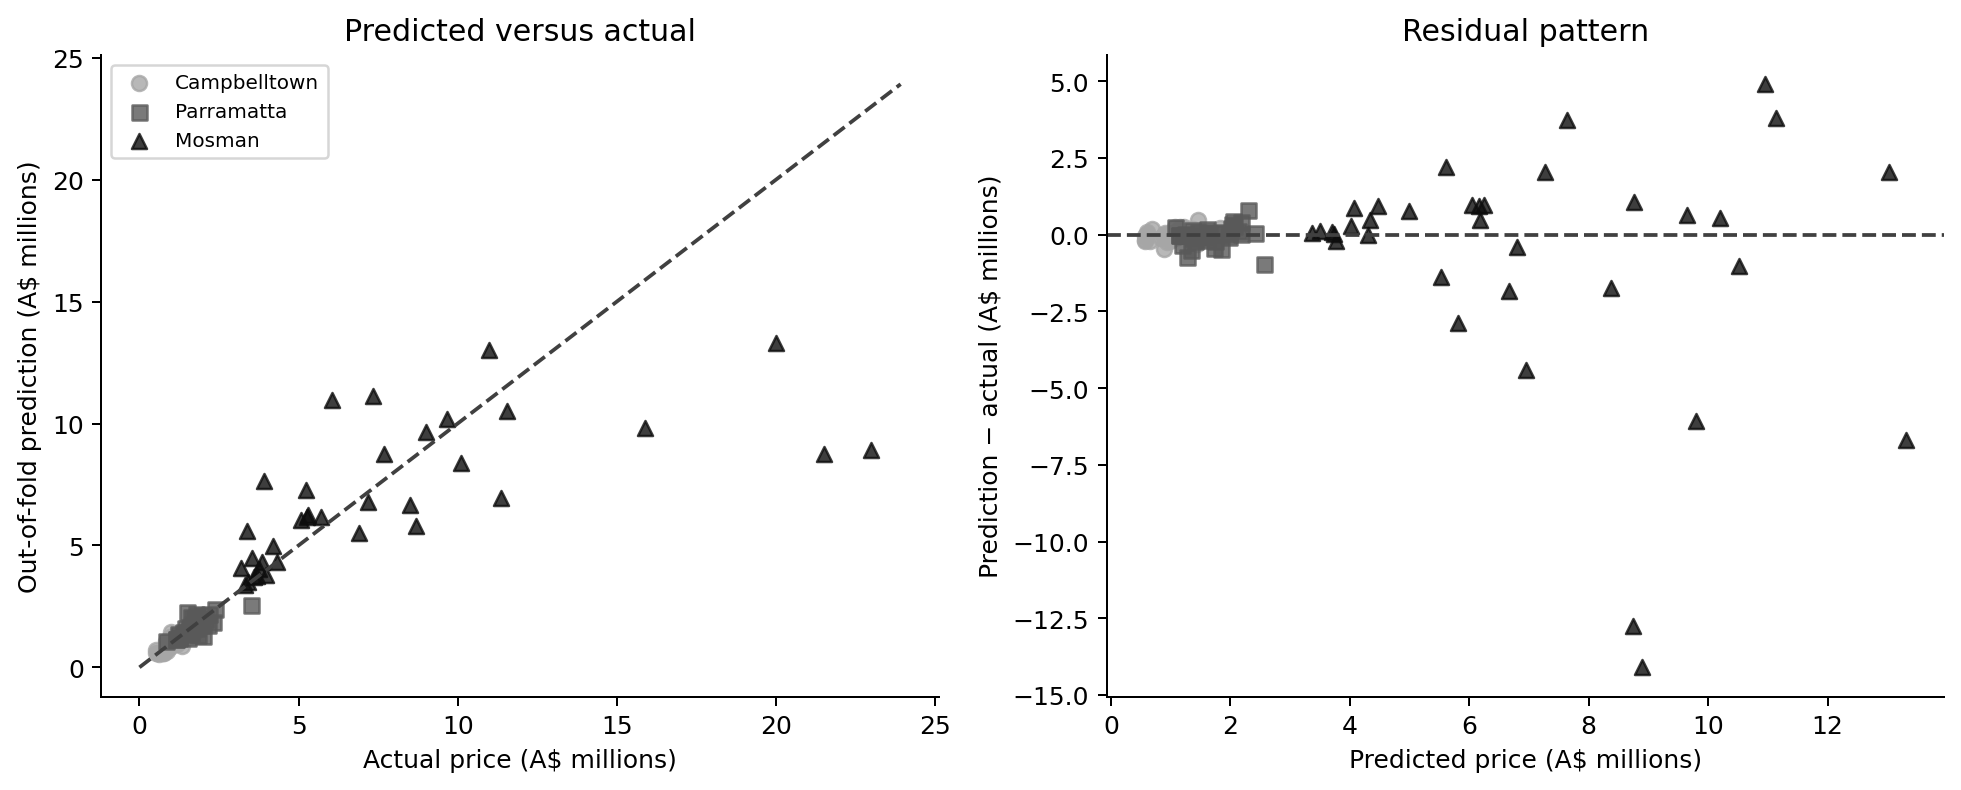

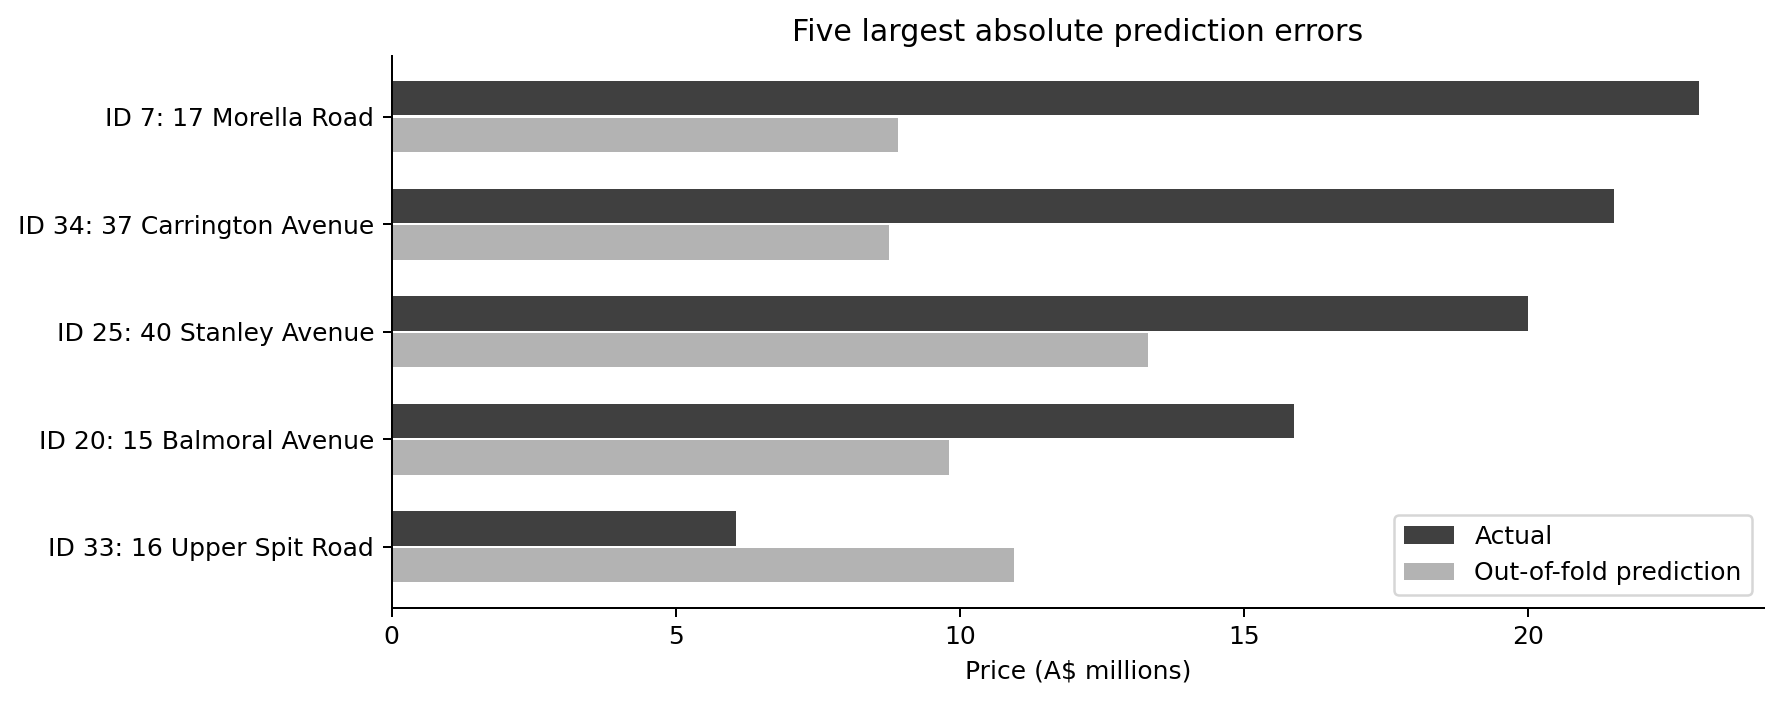

In [15]:
predictions = df.copy()
predictions["outer_fold"] = fold_assignment
for name, values in oof_predictions.items():
    predictions["oof_" + name.lower().replace(" ", "_").replace("-", "_")] = values
predictions["predicted_sale_price"] = oof_predictions[winner]
predictions["signed_error_AUD"] = predictions.predicted_sale_price - predictions.sale_price
predictions["absolute_error_AUD"] = predictions.signed_error_AUD.abs()
predictions["absolute_percentage_error"] = 100 * predictions.absolute_error_AUD / predictions.sale_price
predictions.to_csv(TABLE_DIR / "all_out_of_fold_predictions.csv", index=False)
top5 = predictions.nlargest(5, "absolute_error_AUD")
failure_columns = ["property_id", "address", "sale_date", "sale_price", "predicted_sale_price",
                   "signed_error_AUD", "absolute_error_AUD", "absolute_percentage_error",
                   "bedrooms", "bathrooms", "parking", "land_size_m2", "outer_fold"]
display(top5[failure_columns])
top5[failure_columns + ["source_page", "verification_url"]].to_csv(TABLE_DIR / "five_largest_errors.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for suburb, marker, shade in zip(ordered_suburbs, ["o", "s", "^"], ["0.65", "0.35", "0.05"]):
    part = predictions[predictions.suburb.eq(suburb)]
    axes[0].scatter(part.sale_price / 1e6, part.predicted_sale_price / 1e6,
                    marker=marker, color=shade, alpha=0.8, label=suburb)
    axes[1].scatter(part.predicted_sale_price / 1e6, part.signed_error_AUD / 1e6,
                    marker=marker, color=shade, alpha=0.8)
limit = max(predictions.sale_price.max(), predictions.predicted_sale_price.max()) / 1e6 * 1.04
axes[0].plot([0, limit], [0, limit], "--", color="0.25")
axes[0].set(xlabel="Actual price (A$ millions)", ylabel="Out-of-fold prediction (A$ millions)", title="Predicted versus actual")
axes[0].legend(fontsize=8)
axes[1].axhline(0, color="0.25", linestyle="--")
axes[1].set(xlabel="Predicted price (A$ millions)", ylabel="Prediction − actual (A$ millions)", title="Residual pattern")
show_and_save(fig, "07_prediction_diagnostics")

fig, ax = plt.subplots(figsize=(10, 4))
pos = np.arange(5)
ax.barh(pos-0.17, top5.sale_price / 1e6, height=0.32, color="0.25", label="Actual")
ax.barh(pos+0.17, top5.predicted_sale_price / 1e6, height=0.32, color="0.7", label="Out-of-fold prediction")
ax.set_yticks(pos, [f"ID {r.property_id}: {r.address.split(',')[0]}" for r in top5.itertuples()])
ax.invert_yaxis()
ax.set(xlabel="Price (A$ millions)", title="Five largest absolute prediction errors")
ax.legend()
show_and_save(fig, "08_five_largest_errors")

In [16]:
CASE_CONTEXT = {7: {'url': 'https://www.atlas.com.au/property/17-morella-road-mosman-nsw-1p102453', 'context': 'Atlas describes architect-designed accommodation, harbour views and direct access to Chowder Bay. These attributes are absent from the predictors.', 'inference': 'Architectural quality and the waterfront setting could distinguish this luxury property; the model has few comparable sales.'}, 34: {'url': 'https://www.simeonpartners.com.au/AB1P0936/37-carrington-avenue-mosman', 'context': 'The agent lists deep-water frontage, a jetty, pontoon, slipway and a two-level boathouse.', 'inference': 'Specialised waterfront amenities could explain value beyond broad counts of rooms and land area. This property shares an outer fold with 17 Morella Road, excluding both extreme prices from their training data.'}, 25: {'url': 'https://www.simeonpartners.com.au/AB1P1131/40-stanley-avenue-mosman', 'context': 'The agent describes a 920 square metre level parcel, dual street access, water views and Federation building character.', 'inference': 'The recorded land and bathroom counts do not describe frontage, views or architectural character.'}, 20: {'url': 'https://www.15balmoralavenue.com/', 'context': 'The campaign advertises approximately 533 square metres of internal space, a lift, premium finishes and an infinity-edge pool.', 'inference': 'Verified floor area and finish quality could distinguish this accommodation from other five-bedroom houses.'}, 33: {'url': 'https://www.realestate.com.au/sold/property-house-nsw-mosman-146640792', 'context': 'The sold listing also describes renovation, water views and a swimming pool.', 'inference': 'Missing views alone cannot explain this overprediction. Finer location, layout and transaction circumstances remain unmeasured.'}}
case_notes = []
upper_price = df.sale_price.quantile(0.9)
for rank, row in enumerate(top5.itertuples(), 1):
    train_idx, valid_idx = outer_splits[row.outer_fold-1]
    local_peers = df.iloc[train_idx].query("suburb == @row.suburb")
    similar_beds = int((local_peers.bedrooms == row.bedrooms).sum())
    facts = [f"{row.bedrooms} bedrooms, {row.bathrooms} bathrooms, {row.parking} parking spaces",
             f"{len(local_peers)} same-suburb training properties, including {similar_beds} with the same bedroom count"]
    if pd.isna(row.land_size_m2):
        facts.append("land area was missing or withheld and imputed using training data")
    else:
        facts.append(f"recorded usable land area {row.land_size_m2:,.0f} m²")
    if row.sale_price > upper_price:
        facts.append("sale price lies in the highest 10% of this sample")
    if row.sale_price > local_peers.sale_price.max():
        facts.append("actual price exceeds every same-suburb training price in this fold")
    direction = "underpredicted" if row.signed_error_AUD < 0 else "overpredicted"
    source = row.verification_url if pd.notna(row.verification_url) else row.source_page
    case_notes.append(
        f"### Case {rank}: {row.address}\n"
        f"Actual **A${row.sale_price:,.0f}**; predicted **A${row.predicted_sale_price:,.0f}**. "
        f"The model {direction} by **A${row.absolute_error_AUD:,.0f}** "
        f"({row.absolute_percentage_error:.1f}% of the actual price).\n\n"
        f"Recorded evidence: {'; '.join(facts)}.\n\n"
        f"Listing context: {CASE_CONTEXT[row.property_id]['context']} "
        f"[Source]({CASE_CONTEXT[row.property_id]['url']}) (reviewed 4 October 2026).\n\n"
        f"Interpretation: {CASE_CONTEXT[row.property_id]['inference']} "
        "Listing descriptions are advertising claims, not independently measured attributes. "
        "These are plausible explanations, not proven causes of the prediction error.\n"
    )
display(Markdown("\n".join(case_notes)))
(WORK_DIR / "failure_case_notes.md").write_text("\n".join(case_notes), encoding="utf-8")

suburb_error_rows = []
for suburb, group in predictions.groupby("suburb"):
    suburb_error_rows.append({"suburb": suburb, "n": len(group),
        **score_predictions(group.sale_price, group.predicted_sale_price),
        "mean_signed_error_AUD": group.signed_error_AUD.mean(),
        "median_absolute_percentage_error": group.absolute_percentage_error.median()})
suburb_errors = pd.DataFrame(suburb_error_rows).set_index("suburb")
display(suburb_errors)
suburb_errors.to_csv(TABLE_DIR / "errors_by_suburb.csv")


### Case 1: 17 Morella Road, Mosman NSW 2088
Actual **A$23,000,000**; predicted **A$8,900,514**. The model underpredicted by **A$14,099,486** (61.3% of the actual price).

Recorded evidence: 4 bedrooms, 3 bathrooms, 2 parking spaces; 28 same-suburb training properties, including 9 with the same bedroom count; recorded usable land area 961 m²; sale price lies in the highest 10% of this sample; actual price exceeds every same-suburb training price in this fold.

Listing context: Atlas describes architect-designed accommodation, harbour views and direct access to Chowder Bay. These attributes are absent from the predictors. [Source](https://www.atlas.com.au/property/17-morella-road-mosman-nsw-1p102453) (reviewed 4 October 2026).

Interpretation: Architectural quality and the waterfront setting could distinguish this luxury property; the model has few comparable sales. Listing descriptions are advertising claims, not independently measured attributes. These are plausible explanations, not proven causes of the prediction error.

### Case 2: 37 Carrington Avenue, Mosman NSW 2088
Actual **A$21,500,000**; predicted **A$8,742,304**. The model underpredicted by **A$12,757,696** (59.3% of the actual price).

Recorded evidence: 5 bedrooms, 4 bathrooms, 2 parking spaces; 28 same-suburb training properties, including 12 with the same bedroom count; recorded usable land area 751 m²; sale price lies in the highest 10% of this sample; actual price exceeds every same-suburb training price in this fold.

Listing context: The agent lists deep-water frontage, a jetty, pontoon, slipway and a two-level boathouse. [Source](https://www.simeonpartners.com.au/AB1P0936/37-carrington-avenue-mosman) (reviewed 4 October 2026).

Interpretation: Specialised waterfront amenities could explain value beyond broad counts of rooms and land area. This property shares an outer fold with 17 Morella Road, excluding both extreme prices from their training data. Listing descriptions are advertising claims, not independently measured attributes. These are plausible explanations, not proven causes of the prediction error.

### Case 3: 40 Stanley Avenue, Mosman NSW 2088
Actual **A$20,000,000**; predicted **A$13,308,420**. The model underpredicted by **A$6,691,580** (33.5% of the actual price).

Recorded evidence: 5 bedrooms, 5 bathrooms, 2 parking spaces; 28 same-suburb training properties, including 7 with the same bedroom count; recorded usable land area 920 m²; sale price lies in the highest 10% of this sample.

Listing context: The agent describes a 920 square metre level parcel, dual street access, water views and Federation building character. [Source](https://www.simeonpartners.com.au/AB1P1131/40-stanley-avenue-mosman) (reviewed 4 October 2026).

Interpretation: The recorded land and bathroom counts do not describe frontage, views or architectural character. Listing descriptions are advertising claims, not independently measured attributes. These are plausible explanations, not proven causes of the prediction error.

### Case 4: 15 Balmoral Avenue, Mosman NSW 2088
Actual **A$15,880,000**; predicted **A$9,801,816**. The model underpredicted by **A$6,078,184** (38.3% of the actual price).

Recorded evidence: 5 bedrooms, 4 bathrooms, 2 parking spaces; 28 same-suburb training properties, including 12 with the same bedroom count; recorded usable land area 788 m²; sale price lies in the highest 10% of this sample.

Listing context: The campaign advertises approximately 533 square metres of internal space, a lift, premium finishes and an infinity-edge pool. [Source](https://www.15balmoralavenue.com/) (reviewed 4 October 2026).

Interpretation: Verified floor area and finish quality could distinguish this accommodation from other five-bedroom houses. Listing descriptions are advertising claims, not independently measured attributes. These are plausible explanations, not proven causes of the prediction error.

### Case 5: 16 Upper Spit Road, Mosman NSW 2088
Actual **A$6,050,000**; predicted **A$10,951,917**. The model overpredicted by **A$4,901,917** (81.0% of the actual price).

Recorded evidence: 5 bedrooms, 5 bathrooms, 2 parking spaces; 28 same-suburb training properties, including 10 with the same bedroom count; recorded usable land area 712 m².

Listing context: The sold listing also describes renovation, water views and a swimming pool. [Source](https://www.realestate.com.au/sold/property-house-nsw-mosman-146640792) (reviewed 4 October 2026).

Interpretation: Missing views alone cannot explain this overprediction. Finer location, layout and transaction circumstances remain unmeasured. Listing descriptions are advertising claims, not independently measured attributes. These are plausible explanations, not proven causes of the prediction error.


,n,MAE_AUD,RMSE_AUD,R2,mean_signed_error_AUD,median_absolute_percentage_error
suburb,,,,,,
Campbelltown,35,"140,148.508","183,550.241",0.502,"16,935.671",12.897
Mosman,35,"2,326,260.449","3,976,709.318",0.409,"-732,843.917",18.447
Parramatta,35,"227,011.499","325,494.556",0.501,"-21,732.676",10.199


### What the errors mean for this project

The selected model's MAE was about **A$140,149 in Campbelltown**, **A$227,011 in Parramatta** and **A$2,326,260 in Mosman**. This shows why the overall result is not enough on its own. Expensive Mosman properties have a large effect on the dollar error, so I also checked percentage errors.

The five cases suggest that room counts and land size cannot fully describe a luxury property. Condition, internal floor area, views, waterfront access and finish quality may matter, but these are not verified model inputs. The Upper Spit property also advertised water views and was overpredicted, so adding a simple views column would not automatically solve the problem.

Equal suburb counts do not mean that the dataset covers the same range of property types, sale periods or quality in each area. There are no demographic fairness labels, so I cannot use these suburb results to claim demographic fairness.

I would treat the app's estimate as an approximate result from this small dataset. The average cross-validation error is not an uncertainty range for an individual property. More verified property details and comparable sales would be more useful next steps than simply making the model more complex.


## Part 5. Saving the model and building the app

I selected Ridge regression from the model comparison. The next cell tunes that model family again using all 105 properties and then fits the final pipeline for the app. The saved run selected the basic features with `alpha = 0.1`.

I saved the preprocessing and model together so the app uses the same transformations as the notebook. This final fit uses all the available data, so its training predictions are not new test results. The evaluation scores still come from the earlier outer-fold predictions.


In [17]:
final_cv = list(StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED).split(X, X.suburb))
final_search = GridSearchCV(make_estimator(winner, SEED), parameter_grid(winner),
                           scoring="neg_mean_absolute_error", cv=final_cv,
                           n_jobs=CV_JOBS, refit=True, error_score="raise")
final_search.fit(X, y)
final_model = final_search.best_estimator_
model_path = APP_DIR / "housing_price_model.joblib"
joblib.dump(final_model, model_path)
metadata = {"model_name": winner, "n_properties": len(df), "suburbs": sorted(df.suburb.unique().tolist()),
    "date_min": df.sale_date.min(), "date_max": df.sale_date.max(),
    "feature_set": final_search.best_params_["regressor__features__feature_set"],
    "best_parameters": final_search.best_params_, "raw_features": RAW_FEATURES,
    "predictive_inputs": housing_utils.required_input_features({"feature_set": final_search.best_params_["regressor__features__feature_set"]}),
    "cv_mae_aud": float(pooled.loc[winner,"MAE_AUD"]),
    "cv_rmse_aud": float(pooled.loc[winner,"RMSE_AUD"]), "cv_r2": float(pooled.loc[winner,"R2"]),
    "numeric_ranges": {c: {"min": float(df[c].min()), "max": float(df[c].max())}
                       for c in ["bedrooms", "bathrooms", "parking", "land_size_m2"]},
    "seed": SEED, "versions": versions, "input_sha256": csv_sha256,
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "validation": "5 outer folds; 3 inner folds; stratification by suburb; family selected using outer MAE",
    "source_limit": "Partial source verification; one land conflict withheld; raw CSV preserved"}
(APP_DIR / "model_metadata.json").write_text(json.dumps(metadata, indent=2))
reloaded_model = joblib.load(model_path)
np.testing.assert_allclose(final_model.predict(X.head(5)), reloaded_model.predict(X.head(5)))
print("Exported model:", winner)
print("Final training-only choices:", final_search.best_params_)
print("Model export and reload predictions agree.")


Exported model: Ridge regression
Final training-only choices: {'regressor__features__feature_set': 'basic', 'regressor__model__alpha': 0.1}
Model export and reload predictions agree.


In [18]:
APP_SOURCE = '"""Local prototype. Run with: python -m streamlit run app.py"""\nfrom pathlib import Path\nimport sys\nimport json\nimport numpy as np\nimport pandas as pd\nimport joblib\nimport streamlit as st\n\nAPP_DIR = Path(__file__).resolve().parent\nsys.path.insert(0, str(APP_DIR))\nfrom housing_utils import required_input_features, predict_properties\n\nst.set_page_config(page_title="Sydney property price explorer", layout="centered")\nst.title("Sydney property price explorer")\nst.caption("SIT307 8.1D | Mosman, Parramatta and Campbelltown")\n\n@st.cache_resource\ndef load_model():\n    return joblib.load(APP_DIR / "housing_price_model.joblib")\n\ntry:\n    metadata = json.loads((APP_DIR / "model_metadata.json").read_text())\n    model = load_model()\nexcept FileNotFoundError:\n    st.error("Run the notebook\'s model-export section first, then restart the application.")\n    st.stop()\n\nst.write("Enter property details to estimate a sale price in Australian dollars.")\nst.info(f"This prototype was trained on {metadata[\'n_properties\']} recorded sold properties from Mosman, Parramatta and Campbelltown. Predictions are indicative and should not be treated as professional valuations.")\nsingle, batch = st.tabs(["One property", "Upload CSV"])\nrequired = required_input_features(metadata)\n\nwith single:\n    with st.form("property_form"):\n        suburb = st.selectbox("Suburb", metadata["suburbs"])\n        a, b = st.columns(2)\n        bedrooms = a.number_input("Bedrooms", min_value=1, max_value=20, value=3, step=1)\n        bathrooms = b.number_input("Bathrooms", min_value=1, max_value=20, value=2, step=1)\n        parking = a.number_input("Parking spaces", min_value=0, max_value=20, value=1, step=1)\n        land_unknown = b.checkbox("Land size unknown", value=False)\n        land = a.number_input("Land size (m²)", min_value=1.0, max_value=100000.0, value=500.0, step=10.0)\n        st.caption("Tick Land size unknown if the property\'s usable land area is unavailable or only a shared-complex area is reported.")\n        # Only appears if a future rerun actually selects engineered features.\n        if metadata["feature_set"] != "basic":\n            valuation_date = b.date_input("Valuation date", value=pd.Timestamp(metadata["date_max"]).date())\n            unit_style = st.checkbox("Unit-style address", value=False)\n        submitted = st.form_submit_button("Estimate sale price")\n    if submitted:\n        row = {"suburb": suburb, "bedrooms": bedrooms, "bathrooms": bathrooms,\n               "parking": parking, "land_size_m2": np.nan if land_unknown else land}\n        if metadata["feature_set"] != "basic":\n            row.update(sale_date=str(valuation_date), unit_style_address=int(unit_style))\n        try:\n            result, warnings = predict_properties(pd.DataFrame([row]), model, metadata)\n            for message in warnings:\n                st.warning(message)\n            st.metric("Estimated sale price", f"A${result.predicted_sale_price_aud.iloc[0]:,.0f}")\n            st.caption(f"Model: {metadata[\'model_name\']}. Cross-validated mean absolute error: A${metadata[\'cv_mae_aud\']:,.0f}. This average error is not an individual prediction interval.")\n            st.dataframe(result[required], hide_index=True)\n        except (ValueError, TypeError, OverflowError) as exc:\n            st.error(str(exc))\n\nwith batch:\n    st.write("Upload a CSV using the template columns. Leave unknown land sizes blank.")\n    template_row = {"suburb": "Parramatta", "bedrooms": 3, "bathrooms": 2,\n                    "parking": 1, "land_size_m2": 500,\n                    "sale_date": metadata["date_max"], "unit_style_address": 0}\n    template = pd.DataFrame([template_row])[required]\n    st.download_button("Download input template", template.to_csv(index=False),\n                       "property_input_template.csv", "text/csv")\n    upload = st.file_uploader("Property features", type=["csv"])\n    if upload is not None:\n        try:\n            supplied = pd.read_csv(upload)\n            result, warnings = predict_properties(supplied, model, metadata)\n            for message in warnings:\n                st.warning(message)\n            st.dataframe(result, hide_index=True)\n            st.download_button("Download predictions", result.to_csv(index=False),\n                               "housing_predictions.csv", "text/csv")\n        except (ValueError, TypeError, OverflowError, UnicodeDecodeError) as exc:\n            st.error(str(exc))\n\nwith st.expander("Model and data limits"):\n    st.write(f"Trained on {metadata[\'n_properties\']} properties. Observed sales: {metadata[\'date_min\']} to {metadata[\'date_max\']}.")\n    st.write("Cross-validation compares properties from these three sampled markets. It does not validate other suburbs or future price movements. Equal suburb counts do not represent Sydney\'s transaction mix. Source data and land-area uncertainty remain limitations.")\n    st.write("Features do not include verified condition, floor area, views, frontage, renovation quality or development rights.")\n'
(APP_DIR / "app.py").write_text(APP_SOURCE, encoding="utf-8")
app_requirements = [f"numpy=={np.__version__}", f"pandas=={pd.__version__}",
                    f"scikit-learn=={sklearn.__version__}", f"joblib=={joblib.__version__}",
                    "streamlit==1.65.0"]
(APP_DIR / "requirements.txt").write_text("\n".join(app_requirements) + "\n")
notebook_requirements = app_requirements + [f"matplotlib=={plt.matplotlib.__version__}", "notebook>=7,<8", "ipykernel>=6,<8"]
(WORK_DIR / "requirements.txt").write_text("\n".join(notebook_requirements) + "\n")
example_inputs = pd.DataFrame([
    {"suburb":"Parramatta", "bedrooms":3, "bathrooms":2, "parking":1,
     "land_size_m2":500.0, "sale_date":df.sale_date.max(), "unit_style_address":0},
    {"suburb":"Campbelltown", "bedrooms":3, "bathrooms":1, "parking":1,
     "land_size_m2":np.nan, "sale_date":df.sale_date.max(), "unit_style_address":1},
])
example_inputs = example_inputs[housing_utils.required_input_features(metadata)]
example_inputs.to_csv(APP_DIR / "example_inputs.csv", index=False)
from housing_utils import validate_inputs, input_warnings
validated_examples = validate_inputs(example_inputs, metadata)
example_predictions = example_inputs.copy()
example_predictions["predicted_sale_price_aud"] = reloaded_model.predict(validated_examples)
display(example_predictions)
print("These are user-input examples, not held-out test observations.")
print("To launch from a Jupyter Terminal or your system terminal:")
print(f'cd "{APP_DIR}"')
print("python -m pip install -r requirements.txt")
print("python -m streamlit run app.py")
# Verify the inference schema and common invalid inputs without retraining.
from housing_utils import predict_properties
batch_result, warnings = predict_properties(example_inputs, reloaded_model, metadata)
assert len(batch_result) == 2 and np.isfinite(batch_result.predicted_sale_price_aud).all()
assert any("imputation" in message for message in warnings)
checks = ["model reload agreement", "five-input batch prediction", "missing-land imputation"]
valid = example_inputs.head(1).copy()
zero_parking = valid.copy()
zero_parking["parking"] = 0
predict_properties(zero_parking, reloaded_model, metadata)
checks.append("zero parking accepted")
invalid_cases = {
    "unsupported suburb rejected": valid.assign(suburb="Unknown suburb"),
    "negative bedroom count rejected": valid.assign(bedrooms=-1),
    "fractional bedroom count rejected": valid.assign(bedrooms=2.5),
    "missing bedroom count rejected": valid.assign(bedrooms=np.nan),
    "non-finite land rejected": valid.assign(land_size_m2=np.inf),
    "non-positive land rejected": valid.assign(land_size_m2=0),
    "missing required column rejected": valid.drop(columns="suburb"),
    "empty input rejected": valid.iloc[:0],
}
for label, invalid in invalid_cases.items():
    try:
        predict_properties(invalid, reloaded_model, metadata)
    except (ValueError, TypeError):
        checks.append(label)
    else:
        raise AssertionError(label)
if metadata["feature_set"] == "basic":
    legacy = example_inputs.assign(sale_date="unused", unit_style_address=99)
    legacy_result, _ = predict_properties(legacy, reloaded_model, metadata)
    np.testing.assert_allclose(batch_result.predicted_sale_price_aud, legacy_result.predicted_sale_price_aud)
    checks.append("unused legacy fields do not affect predictions")
batch_result.to_csv(TABLE_DIR / "app_example_predictions.csv", index=False)
(WORK_DIR / "inference_checks.json").write_text(json.dumps({"checks_passed": checks}, indent=2))
display(Markdown("**Inference checks passed:** " + "; ".join(checks) + "."))


These are user-input examples, not held-out test observations.
To launch from a Jupyter Terminal or your system terminal:
cd "/workspace/scratch/b108e072d98e/output/code/SIT307_8_1D_Project/SIT307_8_1D_outputs/app"
python -m pip install -r requirements.txt
python -m streamlit run app.py


,suburb,bedrooms,bathrooms,parking,land_size_m2,predicted_sale_price_aud
0,Parramatta,3,2,1,500.000,"1,685,714.248"
1,Campbelltown,3,1,1,NaN,"593,856.883"


**Inference checks passed:** model reload agreement; five-input batch prediction; missing-land imputation; zero parking accepted; unsupported suburb rejected; negative bedroom count rejected; fractional bedroom count rejected; missing bedroom count rejected; non-finite land rejected; non-positive land rejected; missing required column rejected; empty input rejected; unused legacy fields do not affect predictions.

### Running the app

After running the notebook, I can start the app from a terminal using the three commands printed above. The folder path will match the location where the notebook was run. The saved outputs currently show the earlier execution location; rerunning the notebook prints the path for the current computer.

1. Open the local URL printed by Streamlit.
2. In **One property**, enter the suburb, bedrooms, bathrooms, parking and land size, then select **Estimate sale price**.
3. If the land size is unknown, tick **Land size unknown**. Zero parking is accepted.
4. In **Upload CSV**, use the downloadable template or `app/example_inputs.csv`, upload the property details and download the predictions.

The selected basic Ridge model uses only these five inputs. Date and address-style fields are supplied internally for compatibility and do not affect its predictions. Older seven-column CSV files are still accepted. Unsupported suburbs and invalid values are rejected.

The saved app examples give **A$947,325** for the single-property Campbelltown example and **A$1,685,714** and **A$593,857** for the two CSV examples. These examples demonstrate the app's operation; they are not additional held-out evaluation results.

Running the notebook or app does not create a public website or sharing link. The complete project package contains the notebook, CSV, model, app files, report and supporting outputs. The separate app package contains the files needed to launch the saved model without retraining.


### My reflection

The main point I took from this project is that a more complex model does not automatically give a better result. I expected Random forest to perform best, but Ridge regression had the lowest validation error. Adding more features also increased the average error for all three models, so I kept the simpler feature set for the app.

Data quality was another important part of the work. Land area and floor area can be confused, and a shared parcel size may not describe an individual property. Leaving uncertain values blank and handling them inside the training pipeline was a more defensible choice than treating an unverified value as correct.

The large Mosman errors show the limits of using only basic property details. A model can have the best overall score in this comparison and still make poor predictions for individual homes. This is why I included the failure cases and displayed the model's limitations in the app.

If I extended the project, I would collect more verified sales from comparable periods and add reliable floor-area, condition, title and waterfront information. I would also test on sales from a later period before making any claim about future-market performance.



In [19]:
run_summary = {
    "model": winner, "input_sha256": csv_sha256, "n_rows": len(df),
    "outer_folds": OUTER_FOLDS, "inner_folds": INNER_FOLDS,
    "reported_metrics": pooled.loc[winner].to_dict(), "best_final_parameters": final_search.best_params_,
    "source_audit": audit, "versions": versions,
    "all_oof_predictions_present": bool(all(np.isfinite(p).all() for p in oof_predictions.values())),
}
(WORK_DIR / "run_summary.json").write_text(json.dumps(run_summary, indent=2, default=int))
readme = f"""SIT307 8.1D — Sydney housing project

1. Open SIT307_8_1D_Manmeet_Kaur.ipynb in Jupyter.
2. Keep sydney_housing_final_105_CLEANED.csv beside the notebook, or use its embedded fallback.
3. Restart the kernel and run all cells. No Google Drive mount is required.
4. Launch the application from the app directory:
   python -m pip install -r requirements.txt
   python -m streamlit run app.py

Measured selected model: {winner}
Pooled out-of-fold MAE: A${pooled.loc[winner,'MAE_AUD']:,.2f}
Pooled out-of-fold RMSE: A${pooled.loc[winner,'RMSE_AUD']:,.2f}
Pooled out-of-fold R2: {pooled.loc[winner,'R2']:.6f}
These are regression metrics, not a classification accuracy percentage.

The raw input CSV is unchanged. The modelling copy leaves land missing for the
seven supplied uncertain records and the 109 Victoria Road land/floor discrepancy.
Imputation is learned inside training folds. Source verification is partial.
Never substitute reported_land_size_m2 for the withheld land_size_m2 values.

The application asks for the five predictors used by the selected basic Ridge.
Date and address-style fields are supplied internally only for compatibility.
Inference checks and example predictions are saved with the analysis outputs.
The final project archive also includes the report and supplied app screenshots.
This local package does not create a hosted application or public sharing URL.

Contents: data, figures, tables, app source/module/model, run summary and requirements.
Keep the app module and model together. Retrain with this notebook if library
versions differ from those in model_metadata.json.
"""
(WORK_DIR / "README.txt").write_text(readme, encoding="utf-8")
archive_path = Path.cwd() / "SIT307_8_1D_Run_Outputs.zip"
with zipfile.ZipFile(archive_path, "w", compression=zipfile.ZIP_DEFLATED) as z:
    for path in sorted(WORK_DIR.rglob("*")):
        if path.is_file() and "__pycache__" not in path.parts:
            z.write(path, str(path.relative_to(WORK_DIR)))
print("Run complete. Save the notebook now to retain all outputs.")
print("The generated archive contains run outputs and application files; add the saved notebook when sharing your submission archive.")
display(FileLink(str(archive_path)))


Run complete. Save the notebook now to retain all outputs.
The generated archive contains run outputs and application files; add the saved notebook when sharing your submission archive.


/workspace/scratch/b108e072d98e/output/code/SIT307_8_1D_Project/SIT307_8_1D_Run_Outputs.zip

## References and where I covered the task


1. Deakin University, **SIT307 8.1D: Machine Learning Mini Project**, supplied task sheet, pp. 1-4.
2. scikit-learn, [Common pitfalls: preprocessing and data leakage](https://scikit-learn.org/stable/common_pitfalls.html).
3. scikit-learn, [Cross-validation](https://scikit-learn.org/stable/modules/cross_validation.html).
4. scikit-learn, [TransformedTargetRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.compose.TransformedTargetRegressor.html).
5. Streamlit, [App testing](https://docs.streamlit.io/develop/api-reference/app-testing) and [CSV file uploader](https://docs.streamlit.io/develop/api-reference/widgets/st.file_uploader).
6. realestate.com.au, [109 Victoria Road sold listing](https://www.realestate.com.au/sold/property-house-nsw-parramatta-146028960) and [property profile](https://www.realestate.com.au/property/109-victoria-rd-parramatta-nsw-2150/), accessed 2 October 2026. The land-area and sale-date differences are explained in Part 1.

| Task part | Where I covered it |
|---|---|
| 1. Problem and data | Prediction aim, suburb comparison, 105 records and data-quality decisions |
| 2. Data understanding and features | Summary tables, plots, initial expectations, feature engineering and feature importance |
| 3. Models and evaluation | Three regression models, nested cross-validation, two baselines and error comparisons |
| 4. Five largest errors | Held-out predictions, property details, listing context and possible explanations |
| 5. App and reflection | Saved pipeline, Streamlit app, single-property and CSV examples, run instructions and reflection |
